Data Limitations: All tournament and prize pool data is sourced from esportsearnings.com. This site relies on community contributions and may be missing tournaments, particularly for mobile and Asian esports titles. Teamfight Tactics data is known to be incomplete, with the most recent tournaments not yet recorded. Findings should be interpreted with this in mind.

In [151]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

## Phase 1: Webscraping

Fetch first url page to begin webscraping: 

In [152]:
url = "https://www.esportsearnings.com/games"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

response = requests.get(url, headers=headers)
print(response.status_code)

200


Parse the HTML:

In [153]:
soup = BeautifulSoup(response.text, "html.parser")
print(soup.prettify()[:1000]) #Print the first 1000 characters of HTML

<!DOCTYPE html>
<html>
 <head>
  <script>
   var __ezHttpConsent={setByCat:function(src,tagType,attributes,category,force,customSetScriptFn=null){var setScript=function(){if(force||window.ezTcfConsent[category]){if(typeof customSetScriptFn==='function'){customSetScriptFn();}else{var scriptElement=document.createElement(tagType);scriptElement.src=src;attributes.forEach(function(attr){for(var key in attr){if(attr.hasOwnProperty(key)){scriptElement.setAttribute(key,attr[key]);}}});var firstScript=document.getElementsByTagName(tagType)[0];firstScript.parentNode.insertBefore(scriptElement,firstScript);}}};if(force||(window.ezTcfConsent&&window.ezTcfConsent.loaded)){setScript();}else if(typeof getEzConsentData==="function"){getEzConsentData().then(function(ezTcfConsent){if(ezTcfConsent&&ezTcfConsent.loaded){setScript();}else{console.error("cannot get ez consent data");force=true;setScript();}});}else{force=true;setScript();console.error("getEzConsentData is not a function");}},};
  </script>

Pass 1: creation of top 100 DataFrame

In [154]:
#Top 5 individual detail boxes
top5_cards = soup.find_all("div", class_= "detail_box_game")

top5_list = []
for card in top5_cards:
    title_div = card.find("div", class_="games_top_games_title")
    stats_div = card.find("div", class_="games_top_games_info_box")

    if not title_div or not stats_div:
        continue

    link_tag = title_div.find("a")
    game_name = link_tag.text.strip()
    game_url = "https://www.esportsearnings.com" + link_tag["href"]

    stats_text = stats_div.text.strip()
    parts = stats_text.split()

    top5_list.append({
        "game": game_name, 
        "url": game_url,
        "all_time_prize_pool": parts[0]
    })

    top5_df = pd.DataFrame(top5_list)

#6-100 Table
table = soup.find("table", class_="detail_list_table") #finds table based on class
rows = table.find_all("tr")

games_list = []

for row in rows[0:]: #Can skip header rows by changing
    cols = row.find_all("td")
    if len(cols) < 3:
        continue

    game_name = cols[1].text.strip()
    link_tag = cols[1].find("a") #goes inside cell to grab hyperlink -- will need for pass 2
    game_url = "https://www.esportsearnings.com" + link_tag["href"] if link_tag else None #prepend the domain to links on page to make full URLs
    prize_pool = cols[2].text.strip()

    games_list.append({
        "game": game_name,
        "url": game_url,
        "all_time_prize_pool": prize_pool
    })

games_df = pd.DataFrame(games_list)
#print(games_df.head(10))

#Combine top 5 and 6-100
games_df = pd.concat([top5_df, games_df], ignore_index=True)
games_df = games_df.drop_duplicates(subset="game").reset_index(drop=True)

print(f"Full list: {len(games_df)} games")
print(games_df.head(10))

Full list: 100 games
                                   game  ...   all_time_prize_pool
0                                Dota 2  ...   $382,278,250.965069
1                              Fortnite  ...  $206,630,752.7311130
2      Counter-Strike: Global Offensive  ...  $162,769,575.2716582
3                     League of Legends  ...   $121,953,068.439680
4                        Arena of Valor  ...   $111,511,257.362291
5  PLAYERUNKNOWN'S BATTLEGROUNDS Mobile  ...        $89,785,122.22
6         PLAYERUNKNOWN’S BATTLEGROUNDS  ...        $67,037,707.91
7                         Rocket League  ...        $54,712,430.56
8                     Rainbow Six Siege  ...        $49,885,252.94
9                      Counter-Strike 2  ...        $49,429,077.86

[10 rows x 3 columns]


Pass 2: Scrape year-by-pear data for each game

In [155]:
all_tournament_data = []

for index, row in games_df.iterrows():
    game_name = row["game"]
    game_url = row["url"] + "/events"

    try: 
        game_response = requests.get(game_url, headers = headers)
        game_soup = BeautifulSoup(game_response.text, "html.parser")

        table = game_soup.find("table", class_= "detail_list_table")

        if table is None: 
            print(f"No events table found for {game_name}, skipping...")
            continue

        rows = table.find_all("tr", class_="format_row highlight")

        for tr in rows:
            date_td = tr.find("td", class_="format_cell detail_list_date")
            tournament_td = tr.find("td", class_="format_cell detail_list_tournament")
            prize_td = tr.find("td", class_="format_cell detail_list_prize")

            if not date_td or not prize_td: 
                continue
            
            # Pull year from the start date
            date_text = date_td.text.strip()
            year = date_text[:4] #dates formatted YYYY-MM-DD
            
            all_tournament_data.append({
                "game": game_name, 
                "date": date_text,
                "year": int(year),
                "tournament": tournament_td.text.strip() if tournament_td else None,
                "prize_pool_usd": prize_td.text.strip(), 
            })

        print(f"✓ Scraped {game_name} - {len(rows)} events")
        time.sleep(1) #wait between requests

    except Exception as e:
        print(f"✗ Error scraping {game_name}: {e}")

tournaments_df = pd.DataFrame(all_tournament_data)
print("Done! Shape:", tournaments_df.shape)
print(tournaments_df.head(15))

✓ Scraped Dota 2 - 1259 events
✓ Scraped Fortnite - 597 events
✓ Scraped Counter-Strike: Global Offensive - 3130 events
✓ Scraped League of Legends - 1688 events
✓ Scraped Arena of Valor - 163 events
✓ Scraped PLAYERUNKNOWN'S BATTLEGROUNDS Mobile - 183 events
✓ Scraped PLAYERUNKNOWN’S BATTLEGROUNDS - 409 events
✓ Scraped Rocket League - 1518 events
✓ Scraped Rainbow Six Siege - 343 events
✓ Scraped Counter-Strike 2 - 519 events
✓ Scraped StarCraft II - 2109 events
✓ Scraped Overwatch - 416 events
✓ Scraped VALORANT - 576 events
✓ Scraped Apex Legends - 213 events
✓ Scraped Hearthstone - 715 events
✓ Scraped CrossFire - 167 events
✓ Scraped Mobile Legends: Bang Bang - 150 events
✓ Scraped Free Fire - 80 events
✓ Scraped Heroes of the Storm - 206 events
✓ Scraped Call of Duty: Warzone - 218 events
✓ Scraped Overwatch 2 - 51 events
✓ Scraped Counter-Strike - 973 events
✓ Scraped SMITE - 63 events
✓ Scraped League of Legends: Wild Rift - 54 events
✓ Scraped Chess.com - 241 events
✓ Scraped

In [156]:
#Remove $ and commas in prize pool column to be able to perform operations
tournaments_df["prize_pool_usd"] = (
    tournaments_df["prize_pool_usd"]
    .str.replace("[$,]", "", regex=True)
    .astype(float)
)

#Sum tournament prize pools within the same game & year
yearly_summary = (
    tournaments_df
    .groupby(["game", "year"])["prize_pool_usd"]
    .sum()
    .reset_index()
)

print(yearly_summary.head(15))

                 game  year  prize_pool_usd
0   Age of Empires II  1999       35,785.86
1   Age of Empires II  2000       86,260.55
2   Age of Empires II  2001      163,541.29
3   Age of Empires II  2002      118,301.52
4   Age of Empires II  2003       17,997.02
5   Age of Empires II  2004       53,465.20
6   Age of Empires II  2005       52,595.91
7   Age of Empires II  2006        6,131.44
8   Age of Empires II  2007       22,988.08
9   Age of Empires II  2008       11,988.36
10  Age of Empires II  2009       14,784.84
11  Age of Empires II  2010       16,039.16
12  Age of Empires II  2011        8,329.00
13  Age of Empires II  2012       24,942.94
14  Age of Empires II  2013       34,684.98


## Phase 2: Save to SQLite

Save DataFrame to SQLite:

In [157]:
import sqlite3

#Connect to database file in project folder
conn = sqlite3.connect("esports.db")

#Save all 3 DataFrames as SQL tables
games_df.to_sql("games", conn, if_exists = "replace", index=False)
tournaments_df.to_sql("tournaments", conn, if_exists="replace", index=False)
yearly_summary.to_sql("yearly_summary", conn, if_exists="replace", index=False)

print('Database saved!')



Database saved!


## Phase 3: Exploratory Data Analysis (EDA) with SQL querying

### Query 1 - Top 10 games by all-time prize pool

In [158]:
query1 = """
SELECT game, all_time_prize_pool
FROM games
LIMIT 10
"""

top_games = pd.read_sql_query(query1, conn)
print(top_games)

                                   game   all_time_prize_pool
0                                Dota 2   $382,278,250.965069
1                              Fortnite  $206,630,752.7311130
2      Counter-Strike: Global Offensive  $162,769,575.2716582
3                     League of Legends   $121,953,068.439680
4                        Arena of Valor   $111,511,257.362291
5  PLAYERUNKNOWN'S BATTLEGROUNDS Mobile        $89,785,122.22
6         PLAYERUNKNOWN’S BATTLEGROUNDS        $67,037,707.91
7                         Rocket League        $54,712,430.56
8                     Rainbow Six Siege        $49,885,252.94
9                      Counter-Strike 2        $49,429,077.86


### Query 2 - Total prize money awarded across all esports, by year

In [159]:
query2 = """
SELECT year, ROUND(SUM(prize_pool_usd), 2) AS total_prize_pool
FROM yearly_summary
WHERE year IS NOT NULL
GROUP BY year
ORDER BY year ASC
"""

yearly_totals = pd.read_sql_query(query2, conn)
print(yearly_totals)

    year  total_prize_pool
0   1998         50,500.00
1   1999        155,004.98
2   2000        253,052.91
3   2001        619,195.74
4   2002        785,612.31
5   2003      1,666,948.56
6   2004      2,030,812.57
7   2005      2,833,239.17
8   2006      4,700,073.68
9   2007      5,683,458.50
10  2008      5,610,366.48
11  2009      3,568,519.95
12  2010      5,264,584.06
13  2011      9,745,747.03
14  2012     14,329,604.38
15  2013     20,813,610.29
16  2014     38,413,255.97
17  2015     66,942,002.93
18  2016    103,917,645.03
19  2017    128,325,867.94
20  2018    182,364,050.12
21  2019    258,716,315.79
22  2020    149,957,663.27
23  2021    270,234,565.52
24  2022    253,866,224.41
25  2023    238,917,723.41
26  2024    191,191,581.12
27  2025     74,182,278.19
28  2026      8,426,136.71


### Query 3 - Most active games by tournament count

In [160]:
query3 = """
SELECT game, COUNT(*) AS total_tournaments
FROM tournaments
WHERE year IS NOT NULL
GROUP BY game
ORDER BY total_tournaments DESC
"""

most_active = pd.read_sql_query(query3, conn)
print(most_active)

                                game  total_tournaments
0   Counter-Strike: Global Offensive               3130
1                       StarCraft II               2109
2                  League of Legends               1688
3            Super Smash Bros. Melee               1650
4                  Age of Empires II               1519
..                               ...                ...
95                          NBA 2K23                  3
96                          NBA 2K22                  3
97                     Madden NFL 24                  2
98                     Madden NFL 23                  2
99                     Madden NFL 22                  2

[100 rows x 2 columns]


### Query 4 - Best single year ever per game

In [161]:
query4 = """
SELECT game, year, MAX(prize_pool_usd) AS peak_prize_pool
FROM yearly_summary
WHERE year IS NOT NULL
GROUP BY game
ORDER BY peak_prize_pool DESC
LIMIT 15
"""

peak_years = pd.read_sql_query(query4, conn)
print(peak_years)

                                    game  year  peak_prize_pool
0                               Fortnite  2019    80,707,759.01
1                                 Dota 2  2021    60,393,658.51
2   PLAYERUNKNOWN'S BATTLEGROUNDS Mobile  2022    30,477,128.85
3       Counter-Strike: Global Offensive  2018    25,599,497.64
4                       Counter-Strike 2  2024    23,607,861.95
5                         Arena of Valor  2022    21,950,399.01
6          PLAYERUNKNOWN’S BATTLEGROUNDS  2021    16,227,527.18
7                      League of Legends  2018    14,530,374.68
8                          Rocket League  2022     9,851,219.27
9                      Rainbow Six Siege  2021     9,229,466.19
10                              VALORANT  2023     8,905,616.09
11                             Overwatch  2019     8,707,268.85
12                               FIFA 23  2023     8,686,622.01
13          Call of Duty: Modern Warfare  2020     7,152,172.00
14                   Heroes of the Storm

### Query 5 (Window Function) - Ranking games within each year by prize pool

In [162]:
query5 = """
SELECT game, year, prize_pool_usd, 
    RANK() OVER (PARTITION BY year ORDER BY prize_pool_usd DESC) AS rank_of_year
FROM yearly_summary
WHERE year IS NOT NULL
ORDER BY year DESC, rank_of_year ASC
LIMIT 10
"""

year_ranking = pd.read_sql_query(query5, conn)
print(year_ranking)

                game  year  prize_pool_usd  rank_of_year
0   Counter-Strike 2  2026    3,464,026.42             1
1      Rocket League  2026    2,516,550.00             2
2   Street Fighter 6  2026    1,297,000.00             3
3           Fortnite  2026      632,643.83             4
4  Age of Empires II  2026      317,183.26             5
5          Chess.com  2026      100,000.00             6
6  Age of Empires IV  2026       66,704.40             7
7           VALORANT  2026       30,000.00             8
8         Brawlhalla  2026        2,028.80             9
9   Counter-Strike 2  2025   16,873,953.95             1


### Query 6 (Self Join) - comparing each game's prize pool year-over-year

In [163]:
query6 = """
SELECT
    a.game, 
    a.year,
    a.prize_pool_usd AS current_year, 
    b.prize_pool_usd AS last_year,
    ROUND(((a.prize_pool_usd - b.prize_pool_usd) / b.prize_pool_usd) * 100, 2) AS pct_growth
FROM yearly_summary a
JOIN yearly_summary b
    ON a.game = b.game
    AND a.year = b.year + 1
WHERE a.year IS NOT NULL
ORDER BY pct_growth DESC
LIMIT 20
"""

year_pct_growth = pd.read_sql_query(query6, conn)
print(year_pct_growth)

                                game  year  current_year  last_year  pct_growth
0                      Pokemon Unite  2022    976,519.90     500.00  195,203.98
1   Street Fighter V: Arcade Edition  2018  1,770,658.67   1,900.00   93,092.56
2                        Hearthstone  2014  1,124,013.42   1,395.34   80,454.81
3                          Overwatch  2016  2,430,616.97   3,320.00   73,111.35
4                             Halo 3  2019    335,200.00     800.00   41,800.00
5            Super Smash Bros. Melee  2003     15,550.00      40.00   38,775.00
6         Magic: The Gathering Arena  2019  2,998,000.00  10,000.00   29,880.00
7                        Overwatch 2  2022  6,110,257.00  24,000.00   25,359.40
8                          rFactor 2  2017  1,004,694.66   4,723.91   21,168.29
9                Heroes of the Storm  2015  2,555,140.78  16,757.50   15,147.74
10                 Halo 5: Guardians  2016  3,412,490.03  28,490.94   11,877.46
11                       Shadowverse  20

### Query 7 (CASE WHEN) - categorizing games by era

In [164]:
query7 = """
SELECT game, year, prize_pool_usd, 
    CASE
        WHEN year < 2015 THEN 'Early Era'
        WHEN year BETWEEN 2015 AND 2018 THEN 'Growth Era'
        WHEN year BETWEEN 2019 AND 2021 THEN 'Peak Era'
        ELSE 'Modern Era'
    END AS era
FROM yearly_summary
WHERE year IS NOT NULL
ORDER BY game, year
LIMIT 10
"""

games_by_era = pd.read_sql_query(query7, conn)
print(games_by_era)

                game  year  prize_pool_usd        era
0  Age of Empires II  1999       35,785.86  Early Era
1  Age of Empires II  2000       86,260.55  Early Era
2  Age of Empires II  2001      163,541.29  Early Era
3  Age of Empires II  2002      118,301.52  Early Era
4  Age of Empires II  2003       17,997.02  Early Era
5  Age of Empires II  2004       53,465.20  Early Era
6  Age of Empires II  2005       52,595.91  Early Era
7  Age of Empires II  2006        6,131.44  Early Era
8  Age of Empires II  2007       22,988.08  Early Era
9  Age of Empires II  2008       11,988.36  Early Era


### Query 8 (Subquery) - Finding games that grew faster than average

In [165]:
query8 = """
SELECT game, 
    ROUND(AVG(prize_pool_usd), 2) AS avg_annual_prize_pool, 
    COUNT(year) AS years_active
FROM yearly_summary
WHERE year IS NOT NULL
GROUP BY game
HAVING avg_annual_prize_pool > (
    SELECT AVG(prize_pool_usd) FROM yearly_summary
)
ORDER BY avg_annual_prize_pool DESC
"""

above_avg_growth = pd.read_sql_query(query8, conn)
print(above_avg_growth)

                                    game  avg_annual_prize_pool  years_active
0                                 Dota 2          26,043,517.21            16
1                               Fortnite          22,728,341.82             9
2       Counter-Strike: Global Offensive          13,878,037.74            13
3   PLAYERUNKNOWN'S BATTLEGROUNDS Mobile          11,968,124.02             8
4                         Arena of Valor          11,151,125.74            10
5                       Counter-Strike 2          10,239,963.12             5
6          PLAYERUNKNOWN’S BATTLEGROUNDS           8,658,046.83             8
7                      League of Legends           7,423,910.13            16
8                      Rainbow Six Siege           4,992,878.35            10
9                               VALORANT           4,770,779.39             7
10                               FIFA 23           4,598,511.08             2
11                             Overwatch           4,482,391.24 

### Query 9 - Games by longest professional scene

In [166]:
query9 = """
SELECT game,
    COUNT(year) AS years_active
FROM yearly_summary
WHERE year IS NOT NULL
GROUP BY game
ORDER BY years_active DESC
LIMIT 10
"""

years_active = pd.read_sql_query(query9, conn)
print(years_active)

                      game  years_active
0        Age of Empires II            28
1  Super Smash Bros. Melee            24
2     StarCraft: Brood War            21
3             WarCraft III            19
4        World of WarCraft            17
5                CrossFire            17
6             StarCraft II            16
7        League of Legends            16
8                   Dota 2            16
9           Counter-Strike            16


### Query 10 - Games that have already peaked

In [167]:
query10 = """
SELECT
    a.game, 
    a.year AS peak_year, 
    a.prize_pool_usd AS peak_prize_pool,
    b.prize_pool_usd AS most_recent_prize_pool,
    ROUND(((b.prize_pool_usd - a.prize_pool_usd) / a.prize_pool_usd) * 100, 2) as pct_change_from_peak
FROM yearly_summary a
JOIN yearly_summary b
    ON a.game = b.game
    AND b.year = (SELECT MAX(year) FROM yearly_summary WHERE game = a.game)
WHERE a.prize_pool_usd = (SELECT MAX(prize_pool_usd) FROM yearly_summary WHERE game = a.game)
AND a.year < 2018
ORDER BY pct_change_from_peak ASC
"""

dying_games = pd.read_sql_query(query10, conn)
print(dying_games.to_string())

                              game  peak_year  peak_prize_pool  most_recent_prize_pool  pct_change_from_peak
0              Heroes of the Storm       2016     6,616,599.10                2,000.00                -99.97
1                   Counter-Strike       2006     2,259,492.68                1,932.75                -99.91
2           Counter-Strike: Source       2008       909,146.31                1,000.00                -99.89
3      Super Smash Bros. for Wii U       2017       515,656.43                2,000.00                -99.61
4                     StarCraft II       2012     4,635,752.32               21,027.46                -99.55
5                  Quake Champions       2017     1,494,501.91                7,738.00                -99.48
6             StarCraft: Brood War       2008     1,083,420.25                6,613.98                -99.39
7                Halo 5: Guardians       2016     3,412,490.03               34,000.00                -99.00
8                  

## Phase 4: Data visualization time!

In [168]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

In [169]:

# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


### Chart 1: Total Industry Prize Pool by Year

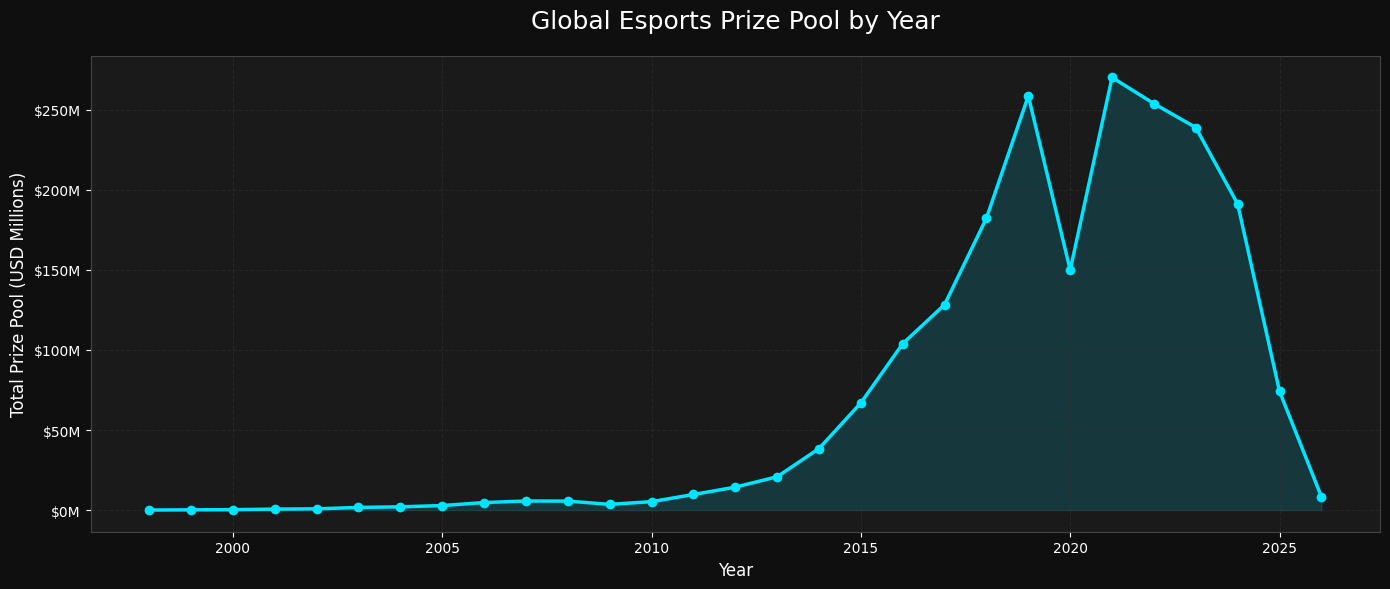

In [170]:
#Pull data
yearly_totals = pd.read_sql_query("""
SELECT year, ROUND(SUM(prize_pool_usd), 2) AS total_prize_pool
FROM yearly_summary
WHERE year IS NOT NULL
GROUP BY year
ORDER BY year ASC
""", conn)

#Blank canvas for graph
fig, ax = plt.subplots(figsize=(14,6))

#Draws the line graph
ax.plot(
    yearly_totals["year"],
    yearly_totals["total_prize_pool"] / 1_000_000,
    color = "#00e5ff",
    linewidth = 2.5,
    marker = "o",
    markersize = 6
)

#Shades area under line
ax.fill_between(
    yearly_totals["year"],
    yearly_totals["total_prize_pool"] / 1_000_000,
    alpha = 0.15,
    color = "#00e5ff"
)

#Titles for plot, axes, etc. 
ax.set_title("Global Esports Prize Pool by Year", fontsize = 18, pad = 20)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Prize Pool (USD Millions)", fontsize = 12)

#Makes y-axis labels monetary values
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))

ax.grid(True)

plt.tight_layout()
plt.show()

### Chart 2: Top 10 Games by All-Time Prize Pool

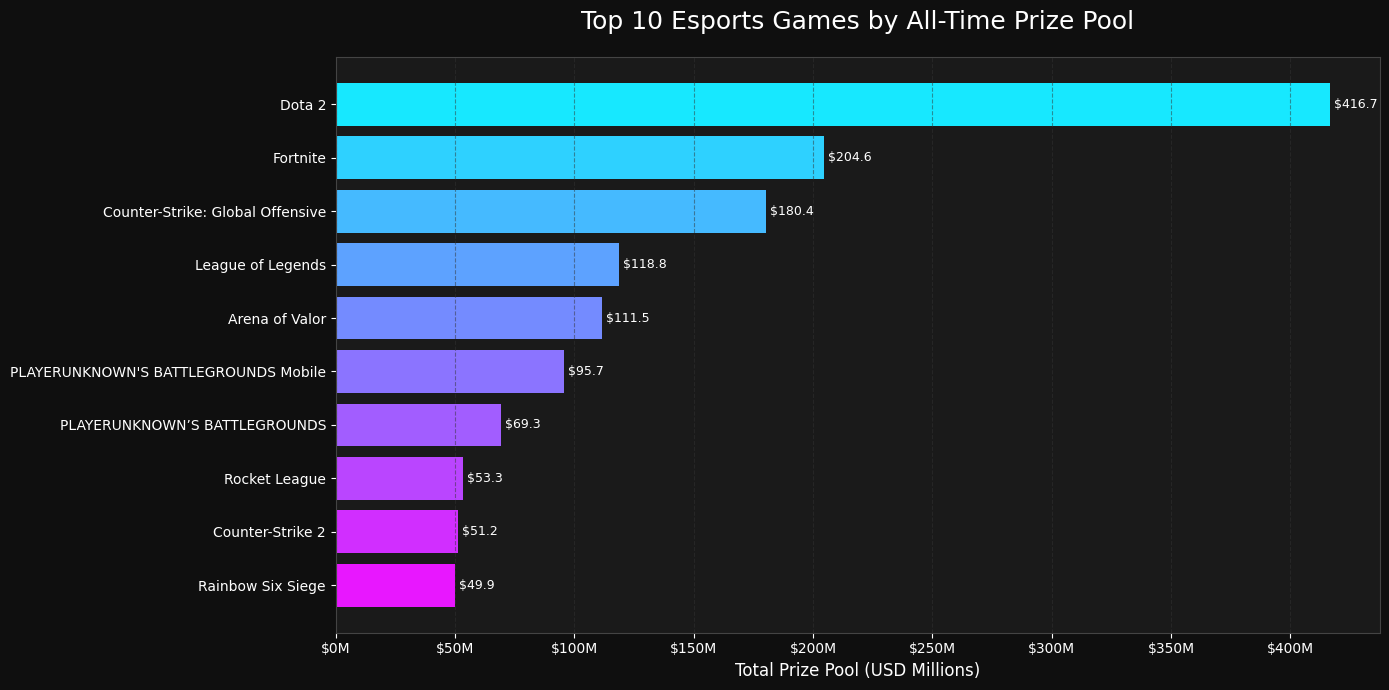

In [171]:
#Pull data
top10 = pd.read_sql_query("""
    SELECT game, SUM(prize_pool_usd) AS total
    FROM yearly_summary
    GROUP BY game
    ORDER BY total DESC
    LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize = (14,7))

colors = sns.color_palette("cool", len(top10))

#Draws bar graph
bars = ax.barh(
    top10["game"],
    top10["total"] /1_000_000, 
    color=colors
)

ax.invert_yaxis()

#Titles for plot, axes, etc.
ax.set_title("Top 10 Esports Games by All-Time Prize Pool", fontsize=18, pad=20)
ax.set_xlabel("Total Prize Pool (USD Millions)", fontsize = 12)

#Makes x-axis labels monetary values
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))

#Add value lables on each bar
ax.bar_label(
    bars, 
    labels = [f"${v:.1f}" for v in top10["total"]/1_000_000],
    padding = 3,
    color="white",
    fontsize=9
)
#for bar in bars:
    #width = bar.get_width()
    #ax.text(
        #width + 0.5, bar.get_y() + bar.get_height()/2, #(x,y) for where our label will sit--y finds the center of the bar in plot.
        #f"${width:.1f}M",
        #va = "center", ha = "left", fontsize=10, color = "white"
    #)

ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

### Chart 3: Top 10 Games Year-Over-Year by Prize Pool

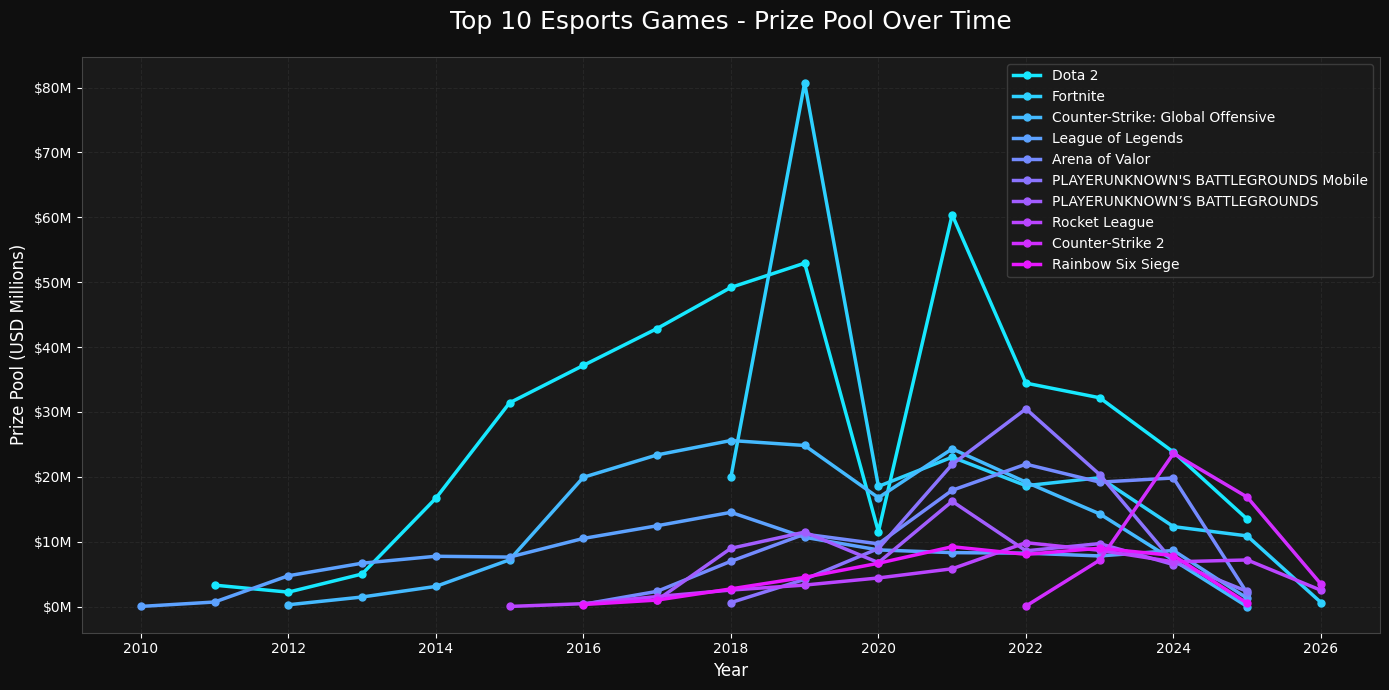

In [172]:
top10_games = pd.read_sql_query("""
    SELECT game, SUM(prize_pool_usd) AS total
    FROM yearly_summary
    GROUP BY game
    ORDER BY total DESC
    LIMIT 10                      
""", conn)["game"].tolist() #converts to Python list [_,...,_]

top10_data = pd.read_sql_query("""
    SELECT game, year, prize_pool_usd
    FROM yearly_summary
    WHERE game in ({})
    AND year IS NOT NULL
    AND year >= 2010
    ORDER BY year ASC                                  
""".format(",".join([f'"{g}"' for g in top10_games])), conn) #f'"{g}"' wraps game names in quotes, ",".join() forms a list out of them, .format() drops the string into {} placeholder

fig, ax = plt.subplots(figsize =(14,7))

colors = sns.color_palette("cool", len(top10_games))

for i, game in enumerate(top10_games):
    game_data = top10_data[top10_data["game"] == game]
    ax.plot(
        game_data["year"],
        game_data["prize_pool_usd"] / 1_000_000,
        label = game,
        color = colors[i], 
        linewidth = 2.5,
        marker = "o", 
        markersize = 5
    )

ax.set_title("Top 10 Esports Games - Prize Pool Over Time", fontsize = 18, pad = 20)
ax.set_xlabel("Year", fontsize = 12)
ax.set_ylabel("Prize Pool (USD Millions)", fontsize = 12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}M"))
ax.legend(facecolor = "#1a1a1a", edgecolor = "#444444", labelcolor = "white")
ax.grid(True)

plt.tight_layout()
plt.show()

### Chart 4: Popularity by Era Heatmap

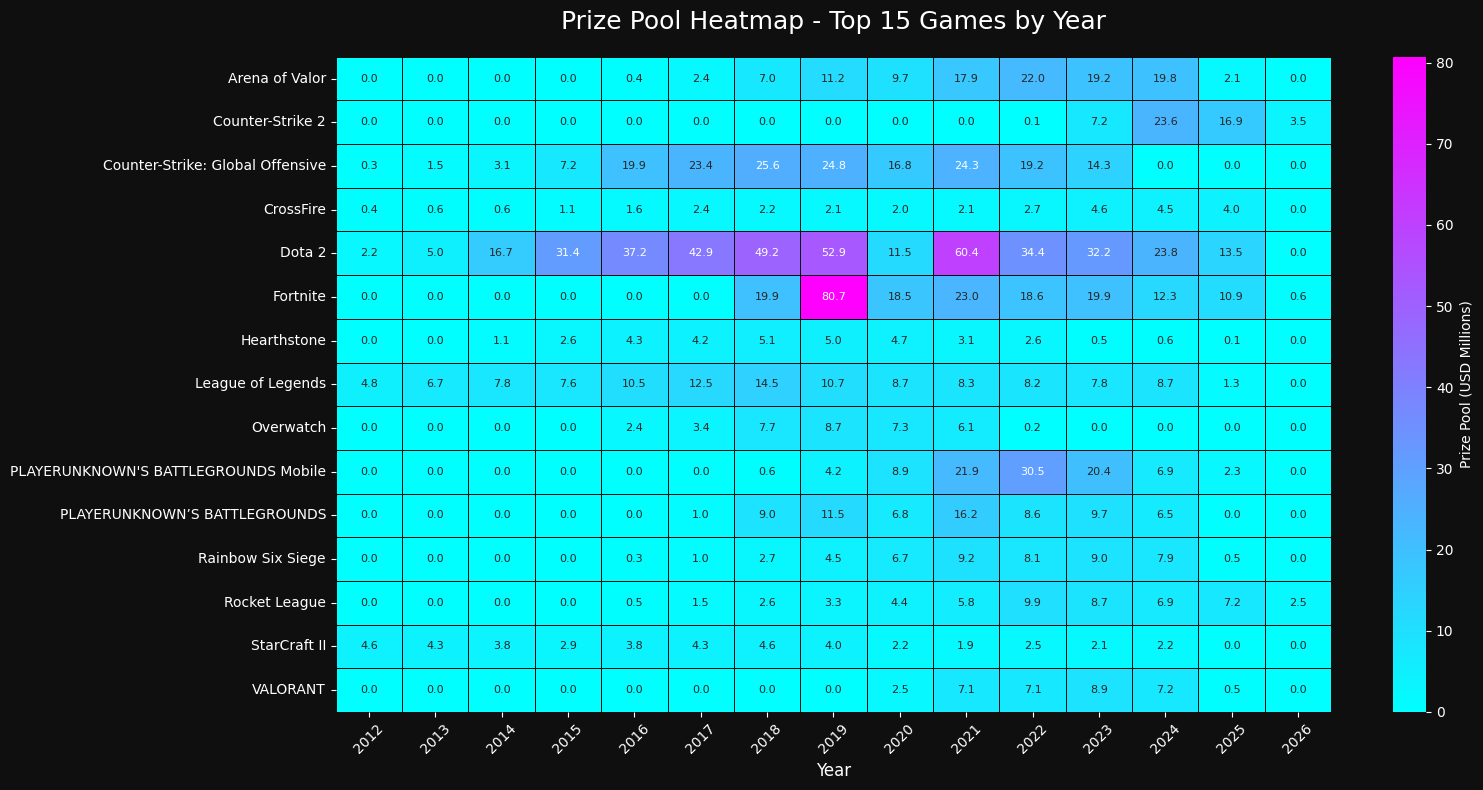

In [173]:
heatmap_data = pd.read_sql_query("""
    SELECT game, year, prize_pool_usd
    FROM yearly_summary
    WHERE year IS NOT NULL
    AND year >= 2012
    AND game IN (
        SELECT game FROM yearly_summary
        GROUP BY game
        ORDER BY SUM(prize_pool_usd) DESC                        
        LIMIT 15
    )
    ORDER BY year ASC
""", conn)

#Restructure dataframe from one row per game/year combo to each row is a game, each column a year
heatmap_pivot = heatmap_data.pivot_table(
    index="game",
    columns = "year", 
    values = "prize_pool_usd",
    aggfunc = "sum"
).fillna(0) / 1_000_000 #fill blanks and convert to millions

fig, ax = plt.subplots(figsize = (16,8))

sns.heatmap(
    heatmap_pivot, 
    ax = ax,
    cmap = "cool",
    linewidths = 0.5,
    linecolor = "#0f0f0f",
    annot = True, #prints cell values inside
    fmt = ".1f", #formats cell values to 1 decimal pt
    annot_kws={"size": 8}, #setting fontsize to 8 for annotations
    cbar_kws={"label": "Prize Pool (USD Millions)"} #color bar on side of plot
)

ax.set_title("Prize Pool Heatmap - Top 15 Games by Year", fontsize = 18, pad=20)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

### Chart 5: New Era Games (I have a particular interest in TFT)

In [174]:
#indented MIN(year) & such so that MIN(year) is calculated before the WHERE year >= 2018 filtering
new_era_options = pd.read_sql_query("""
    SELECT game, 
        MIN(year) as first_year, 
        ROUND(SUM(prize_pool_usd), 2) AS total_prize_pool
    FROM yearly_summary
    WHERE year IS NOT NULL
    GROUP BY game
    HAVING first_year >= 2018
    ORDER BY total_prize_pool DESC
""", conn)

print(new_era_options.to_string())

                                    game  first_year  total_prize_pool
0                               Fortnite        2018    204,555,076.42
1   PLAYERUNKNOWN'S BATTLEGROUNDS Mobile        2018     95,744,992.15
2                       Counter-Strike 2        2022     51,199,815.61
3                               VALORANT        2020     33,395,455.75
4                           Apex Legends        2019     29,803,237.01
5                              Free Fire        2019     20,448,992.14
6                            Overwatch 2        2021     14,787,376.59
7                  Call of Duty: Warzone        2020     13,854,809.95
8                   Call of Duty: Mobile        2019     11,379,268.75
9           League of Legends: Wild Rift        2021     11,241,403.16
10                     Teamfight Tactics        2019     11,056,083.69
11            Magic: The Gathering Arena        2018      9,794,000.00
12                               FIFA 23        2022      9,197,022.16
13    

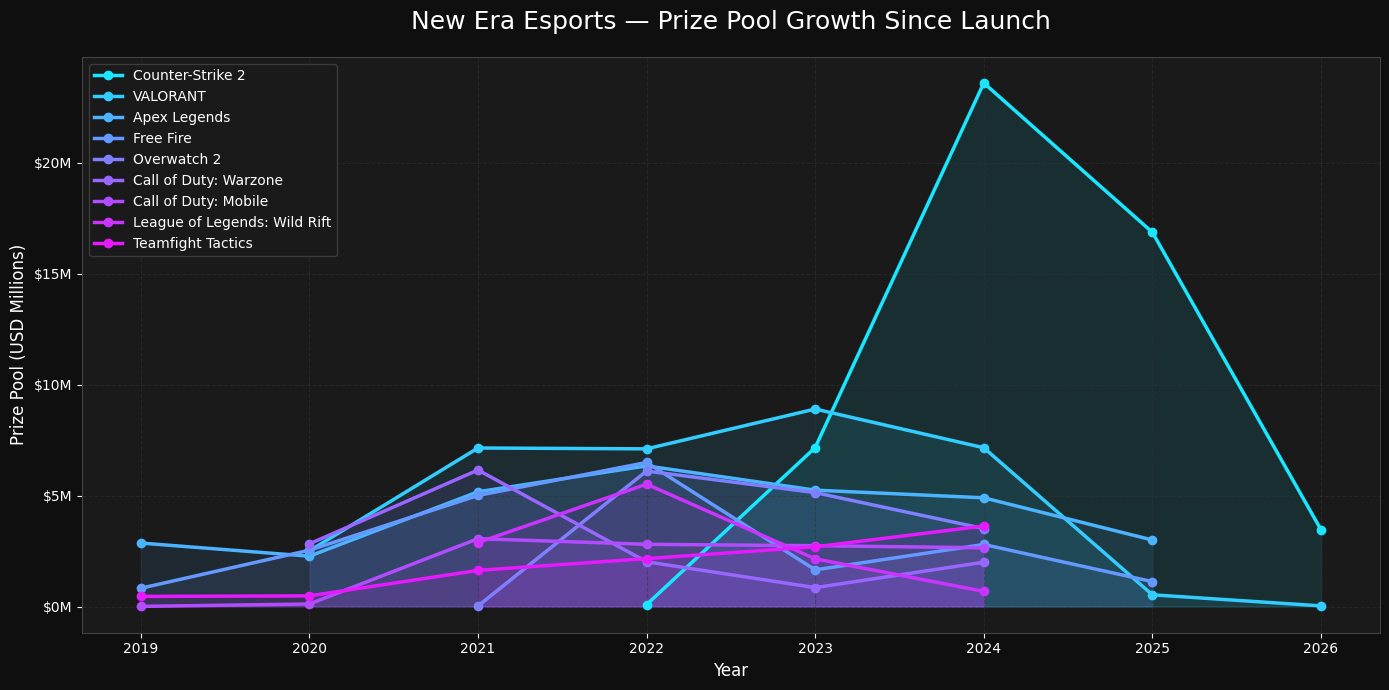

In [175]:
new_era_games = ["Counter-Strike 2", "VALORANT", "Apex Legends", "Free Fire", "Overwatch 2", "Call of Duty: Warzone", "Call of Duty: Mobile", "League of Legends: Wild Rift", "Teamfight Tactics"]

new_era_data = pd.read_sql_query("""
    SELECT game, year, prize_pool_usd
    FROM yearly_summary
    WHERE game IN ("Counter-Strike 2", "VALORANT", "Apex Legends", "Free Fire", "Overwatch 2", "Call of Duty: Warzone", "Call of Duty: Mobile", "League of Legends: Wild Rift", "Teamfight Tactics")
    AND year IS NOT NULL
    ORDER BY year ASC
""", conn)

fig, ax = plt.subplots(figsize=(14,7))

colors = sns.color_palette("cool", len(new_era_games))

for i, game in enumerate(new_era_games):
    game_data = new_era_data[new_era_data["game"] == game]
    ax.plot(
        game_data["year"],
        game_data["prize_pool_usd"] / 1_000_000, 
        label=game, 
        color=colors[i],
        linewidth=2.5,
        marker="o",
        markersize=6
    )
    ax.fill_between(
        game_data["year"], 
        game_data["prize_pool_usd"] / 1_000_000, 
        alpha = 0.1, 
        color = colors[i]
    )

ax.set_title("New Era Esports — Prize Pool Growth Since Launch", fontsize=18, pad=20)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Prize Pool (USD Millions)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(facecolor="#1a1a1a", edgecolor="#444444", labelcolor="white")
ax.grid(True)

plt.tight_layout()
plt.show()

### Chart 6: Games With Largest Decline From Peak

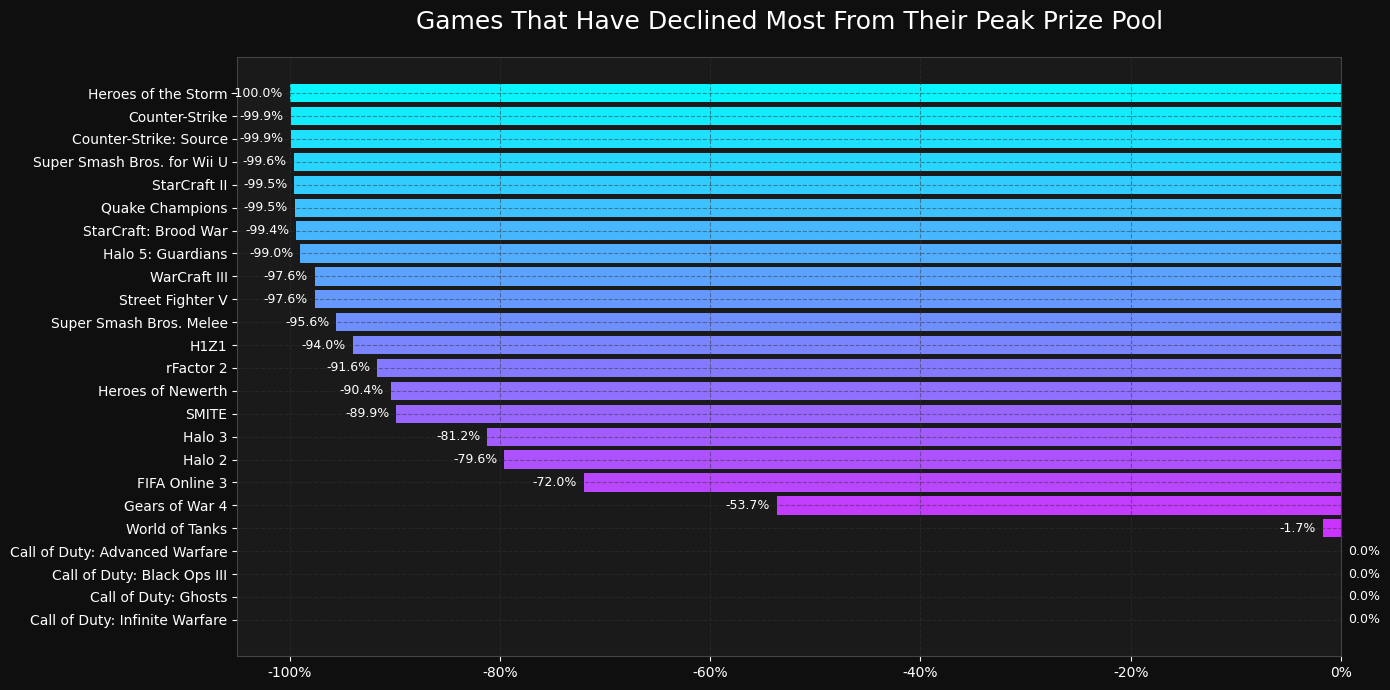

In [176]:
fig, ax = plt.subplots(figsize=(14,7))

colors = sns.color_palette("cool", len(dying_games))

bars = ax.barh(
    dying_games["game"], 
    dying_games["pct_change_from_peak"],
    color=colors
)

ax.invert_yaxis()
ax.set_title("Games That Have Declined Most From Their Peak Prize Pool", fontsize = 18, pad = 20)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

#Adding labels to each bar
ax.bar_label(
    bars,
    labels=[f"{v:.1f}%" for v in dying_games["pct_change_from_peak"]],
    padding = 5, 
    color = "white",
    fontsize=9
)

ax.grid(True)

plt.tight_layout()
plt.show()

## Phase 5: Predicting Future Growth

A train/test split is not implemented due to limited yearly data points per game. Future iterations of this model would benefit from a training set and test set, i.e. train on older years, test on most recent 2-3 years (or 20% of data points).

##### Data prep: pulling clean yearly data for all games and then ruling out games with less than 4 years of data. 

In [177]:
from sklearn.linear_model import LinearRegression
import numpy as np

#Pull clean yearly data for all games
model_data = pd.read_sql_query("""
    SELECT game, year, prize_pool_usd
    FROM yearly_summary
    WHERE year IS NOT NULL
    AND year >= 2012 AND year <= 2025
    ORDER BY game, year ASC
""", conn)

#Rule out games with less than 4 years of data -- not enough data to reliably predict those games
game_counts = model_data.groupby("game")["year"].count()
valid_games = game_counts[game_counts >= 4].index
model_data = model_data[model_data["game"].isin(valid_games)]

print(f"Games with enough data to model: {len(valid_games)}")
print(model_data.head(10))

Games with enough data to model: 71
                game  year  prize_pool_usd
0  Age of Empires II  2012       24,942.94
1  Age of Empires II  2013       34,684.98
2  Age of Empires II  2014      177,354.00
3  Age of Empires II  2015       81,091.83
4  Age of Empires II  2016       77,756.14
5  Age of Empires II  2017       80,771.43
6  Age of Empires II  2018      123,432.23
7  Age of Empires II  2019       85,159.31
8  Age of Empires II  2020      391,476.29
9  Age of Empires II  2021      634,375.76


#### Linear Regression:

In [178]:
future_years = np.array([2026, 2027, 2028]).reshape(-1, 1) #converts flat list into column to use in scikit-learn
predictions = []

for game in valid_games: 
    game_df = model_data[model_data["game"] == game]

    x = game_df["year"].values.reshape(-1,1) # input: years
    y = game_df["prize_pool_usd"].values # output: prize pools

    model = LinearRegression()
    model.fit(x, y)

    r_squared = model.score(x,y)
    predicted_values = model.predict(future_years)

    for year, value in zip([2026, 2027, 2028], predicted_values): #zip loops through years and predicted values simultaneously
        predictions.append({
            "game": game, 
            "year": year, 
            "predicted_prize_pool": max(0, round(value, 2)), 
            "r_squared_linear": round(r_squared, 3)
        })

predictions_df = pd.DataFrame(predictions)

linear_display_df = predictions_df.copy()
linear_display_df["predicted_prize_pool"] = linear_display_df["predicted_prize_pool"].apply(lambda x: f"${x:,.2f}")
linear_display_df["r_squared_linear"] = linear_display_df["r_squared_linear"].apply(lambda x: f"{x:,.3f}")

#pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(linear_display_df.to_string())

                                     game  year predicted_prize_pool r_squared_linear
0                       Age of Empires II  2026          $656,910.70            0.727
1                       Age of Empires II  2027          $707,012.07            0.727
2                       Age of Empires II  2028          $757,113.45            0.727
3                       Age of Empires IV  2026          $224,043.94            0.023
4                       Age of Empires IV  2027          $200,039.51            0.023
5                       Age of Empires IV  2028          $176,035.08            0.023
6                            Apex Legends  2026        $5,078,767.03            0.084
7                            Apex Legends  2027        $5,284,057.47            0.084
8                            Apex Legends  2028        $5,489,347.90            0.084
9                          Arena of Valor  2026       $19,127,504.72            0.290
10                         Arena of Valor  2027       

#### Polynomial Regression:

In [179]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

future_years = np.array([2026, 2027, 2028]).reshape(-1,1)
poly_predictions = []

for game in valid_games:
    game_df = model_data[model_data["game"] == game]

    x = game_df["year"].values.reshape(-1,1)
    y = game_df["prize_pool_usd"].values

    #create pipeline with polynomial degree and model
    poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    #fit the entire sequence at once
    poly_model.fit(x,y)

    r_squared = poly_model.score(x,y)
    predicted_values = poly_model.predict(future_years)

    for year, value in zip([2026, 2027, 2028], predicted_values):
        poly_predictions.append({
            "game": game, 
            "year": year, 
            "predicted_prize_pool": max(0, round(value, 2)), 
            "r_squared_poly": round(r_squared, 3)
        })

poly_df = pd.DataFrame(poly_predictions)

poly_display_df = poly_df.copy()
poly_display_df["predicted_prize_pool"] = poly_display_df["predicted_prize_pool"].apply(lambda x: f"${x:,.2f}")
poly_display_df["r_squared_poly"] = poly_display_df["r_squared_poly"].apply(lambda x: f"{x:,.3f}")

#pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(poly_display_df.head(10).to_string())

                game  year predicted_prize_pool r_squared_poly
0  Age of Empires II  2026          $730,259.04          0.739
1  Age of Empires II  2027          $809,699.76          0.739
2  Age of Empires II  2028          $892,807.89          0.739
3  Age of Empires IV  2026                $0.00          0.185
4  Age of Empires IV  2027                $0.00          0.185
5  Age of Empires IV  2028                $0.00          0.185
6       Apex Legends  2026        $1,175,506.69          0.716
7       Apex Legends  2027                $0.00          0.716
8       Apex Legends  2028                $0.00          0.716
9     Arena of Valor  2026        $4,375,900.35          0.687


#### Holt's Linear Exponential Smoothing:

In [180]:
#from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import Holt

In [181]:
exp_predictions = []

for game in valid_games:
    game_df = model_data[model_data["game"] == game].sort_values("year")

    y = game_df["prize_pool_usd"].values.astype(float)
    years = game_df["year"].values

    try:
        #exp_model = SimpleExpSmoothing(y).fit(optimized=True)
        exp_model = Holt(y).fit(optimized=True)

        #forecast next 3 years 
        forecast = exp_model.forecast(3)

        #Mean Absoluate Error (MAE) on historical data
        fitted = exp_model.fittedvalues
        mae = np.mean(np.abs(fitted - y))

        #Alpha to determine weight given to recent data
        alpha = exp_model.params["smoothing_level"] #weight of year determined by (alpha) * (1-alpha)^n
        beta = exp_model.params["smoothing_trend"] #need in Holt's Linear Smoothing so model can see trend

        for i, year in enumerate([2026, 2027, 2028]):
            exp_predictions.append({
                "game": game, 
                "year": year,
                "predicted_prize_pool": max(0, round(forecast[i], 2)),
                "mae": round(mae, 2), 
                "alpha": round(alpha, 3),
                "beta": round(beta, 3)
        })
        
        #print(f"✓ {game} — alpha: {round(alpha, 3)}, MAE: ${mae:,.0f}")
    
    except Exception as e: 
        print(f"✗ {game}: {e}")

exp_df = pd.DataFrame(exp_predictions)
#print("\nDone!")

display_exp = exp_df.copy()
display_exp["predicted_prize_pool"] = display_exp["predicted_prize_pool"].apply(lambda x: f"${x:,.2f}")
display_exp["mae"] = display_exp["mae"].apply(lambda x: f"${x:,.2f}")
display_exp["alpha"] = display_exp["alpha"].apply(lambda x: f"{x:.3f}")

print(display_exp.head(10).to_string())

                game  year predicted_prize_pool            mae  alpha  beta
0  Age of Empires II  2026          $495,149.37     $97,594.36  0.927  0.00
1  Age of Empires II  2027          $504,891.41     $97,594.36  0.927  0.00
2  Age of Empires II  2028          $514,633.45     $97,594.36  0.927  0.00
3  Age of Empires IV  2026          $105,951.78    $397,060.26  0.734  0.73
4  Age of Empires IV  2027           $18,719.48    $397,060.26  0.734  0.73
5  Age of Empires IV  2028                $0.00    $397,060.26  0.734  0.73
6       Apex Legends  2026        $2,425,730.96  $1,130,974.75  1.000  0.00
7       Apex Legends  2027        $1,851,461.90  $1,130,974.75  1.000  0.00
8       Apex Legends  2028        $1,277,192.84  $1,130,974.75  1.000  0.00
9     Arena of Valor  2026       $22,312,173.03  $4,395,145.93  0.000  0.00


### Visualizing predicted growth:

#### Chart A - One chart per game:

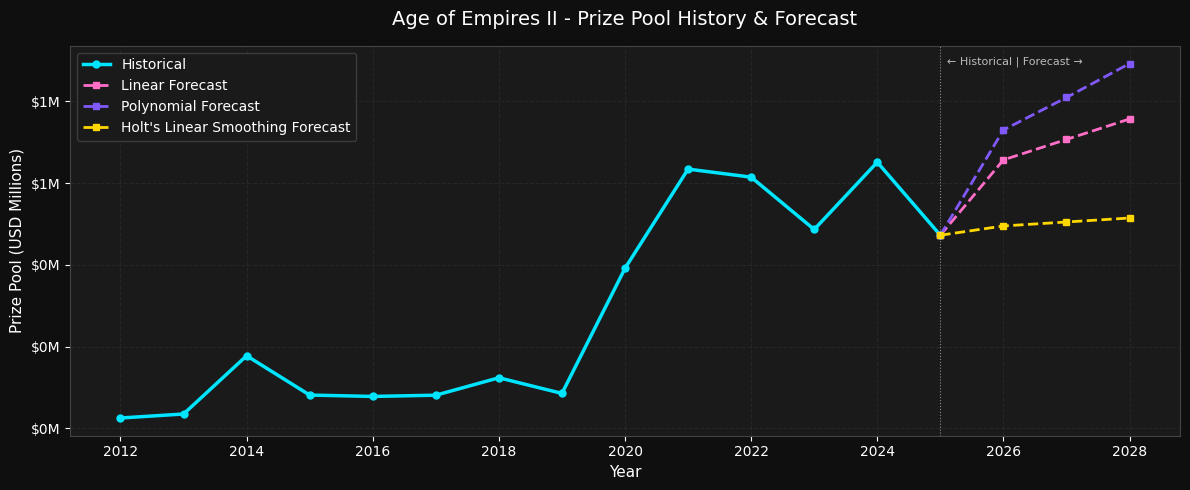

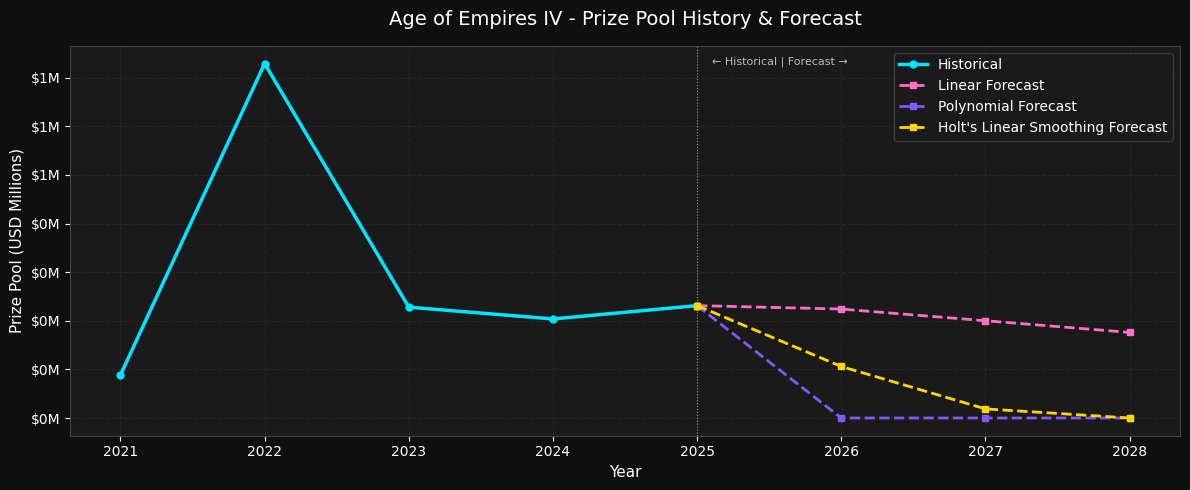

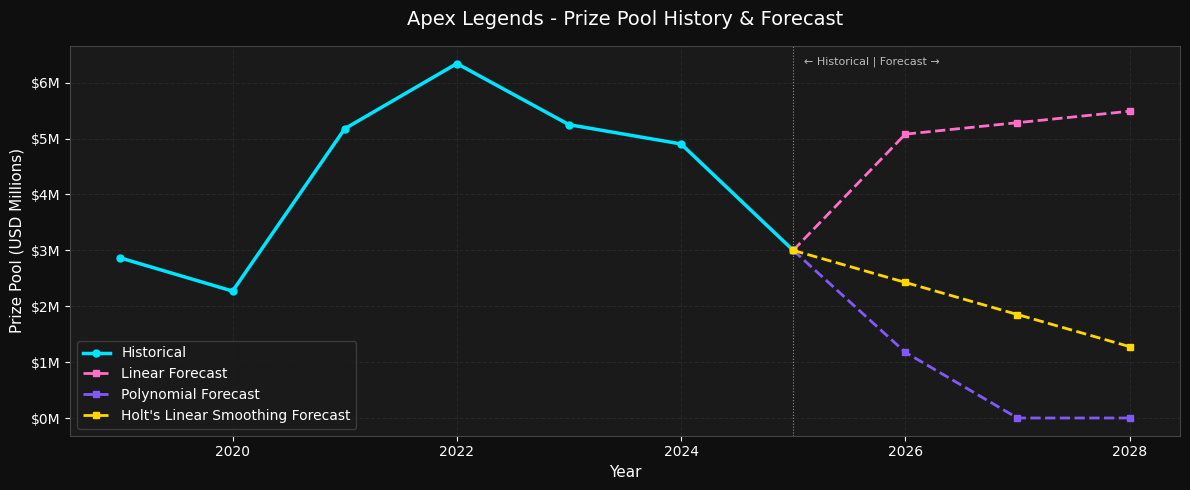

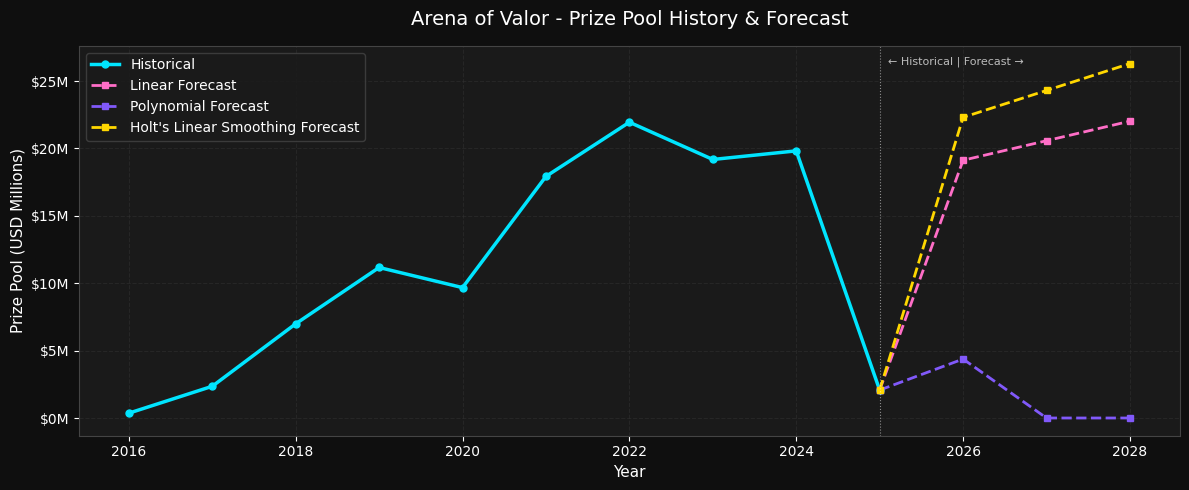

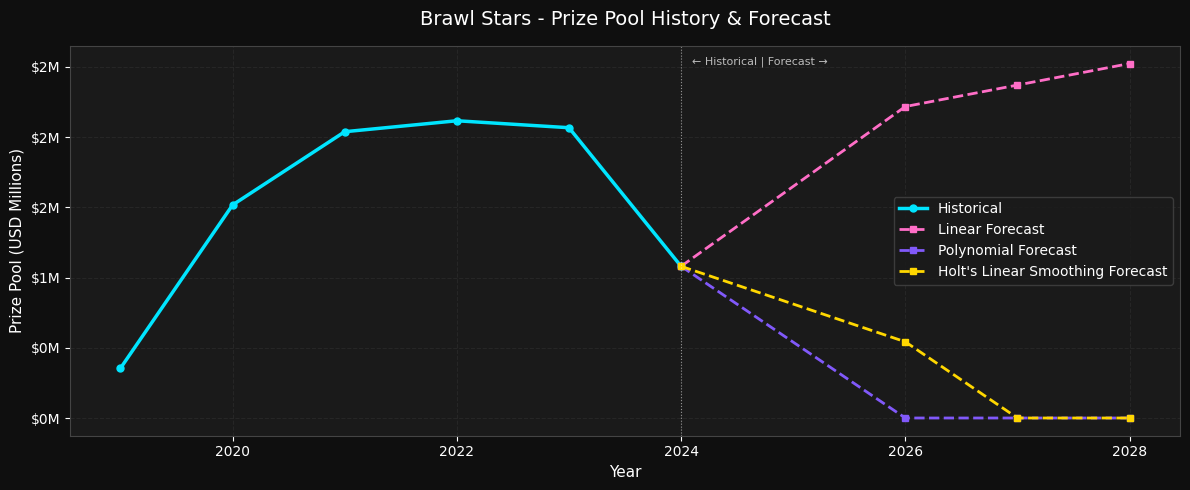

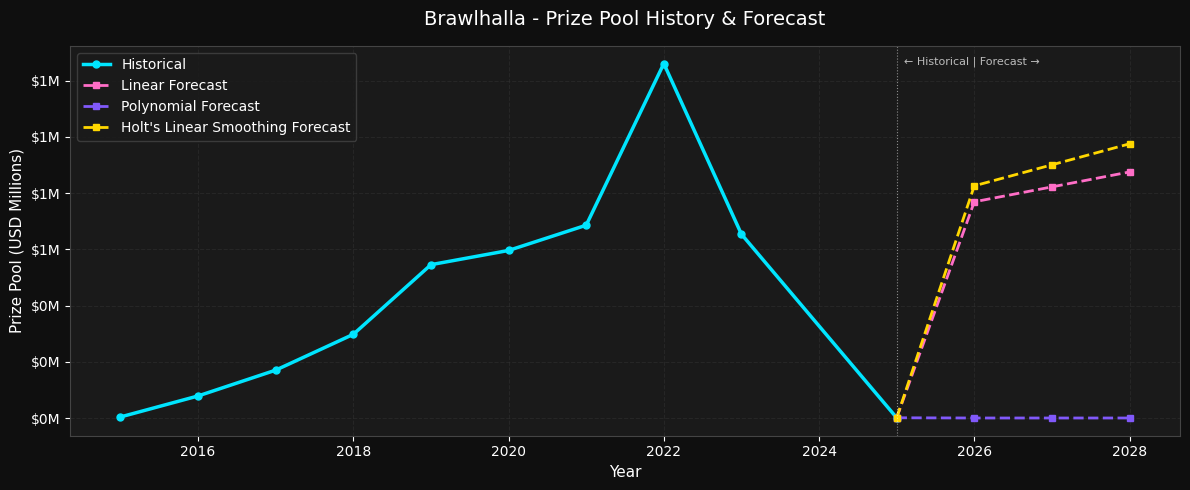

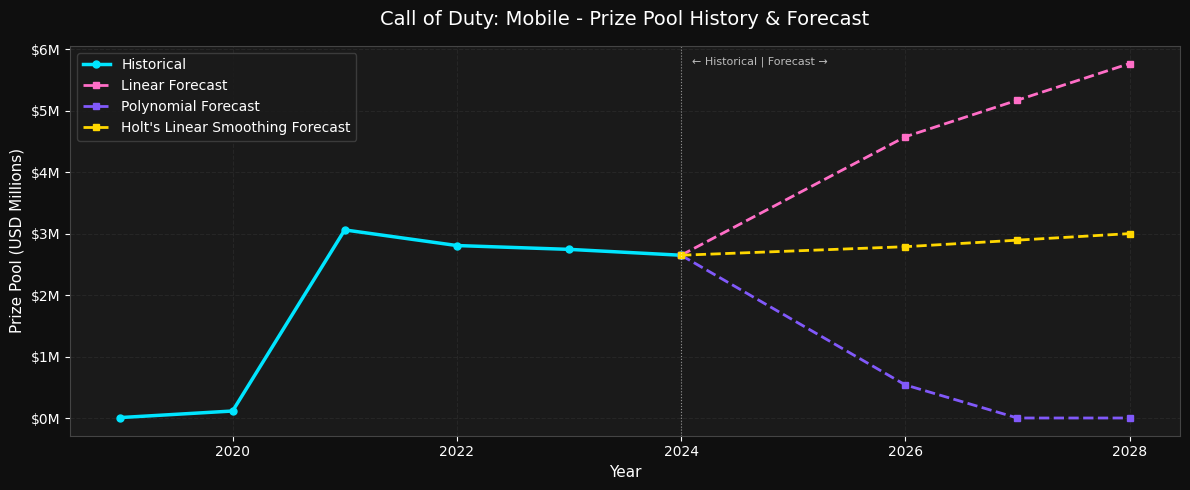

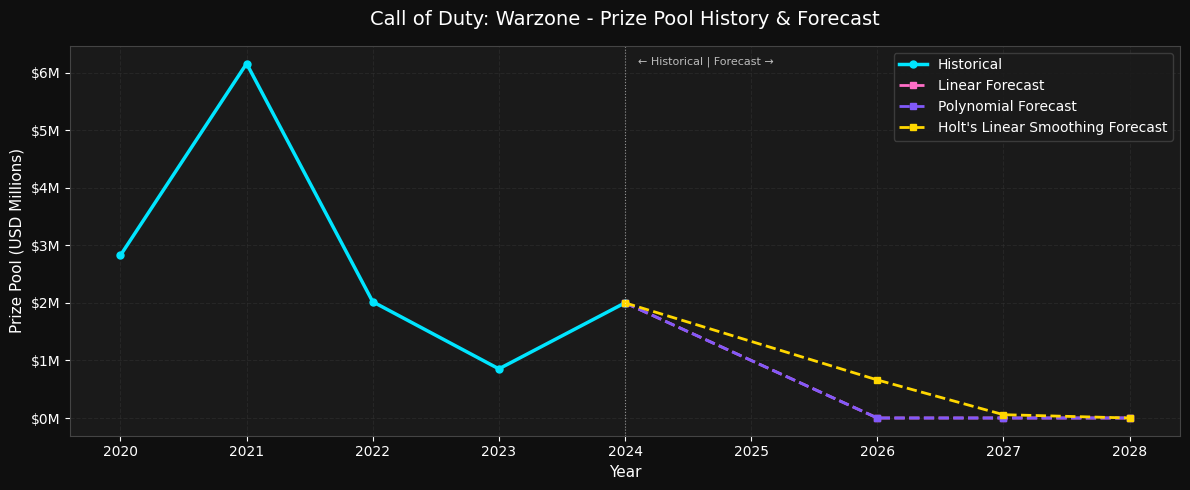

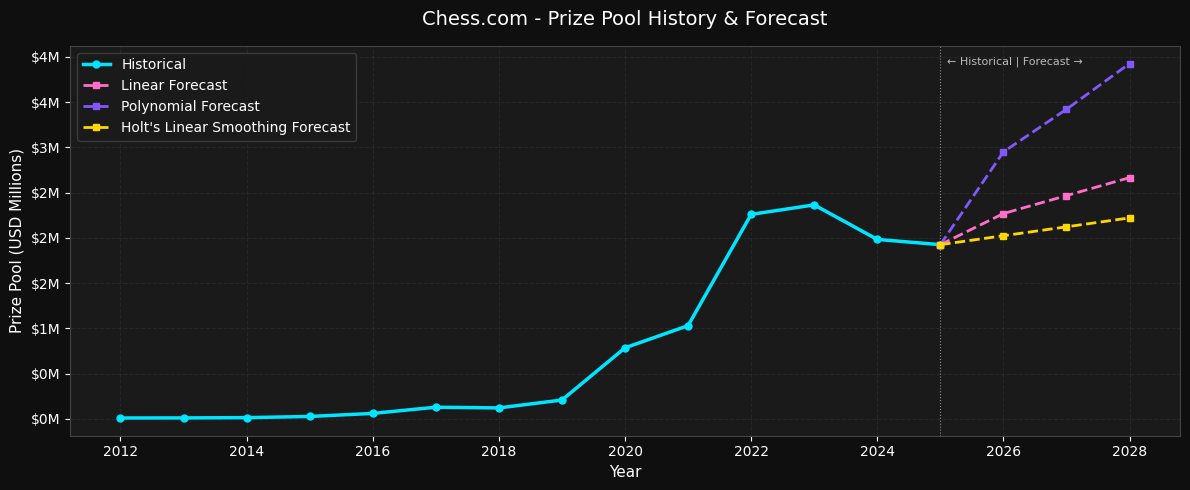

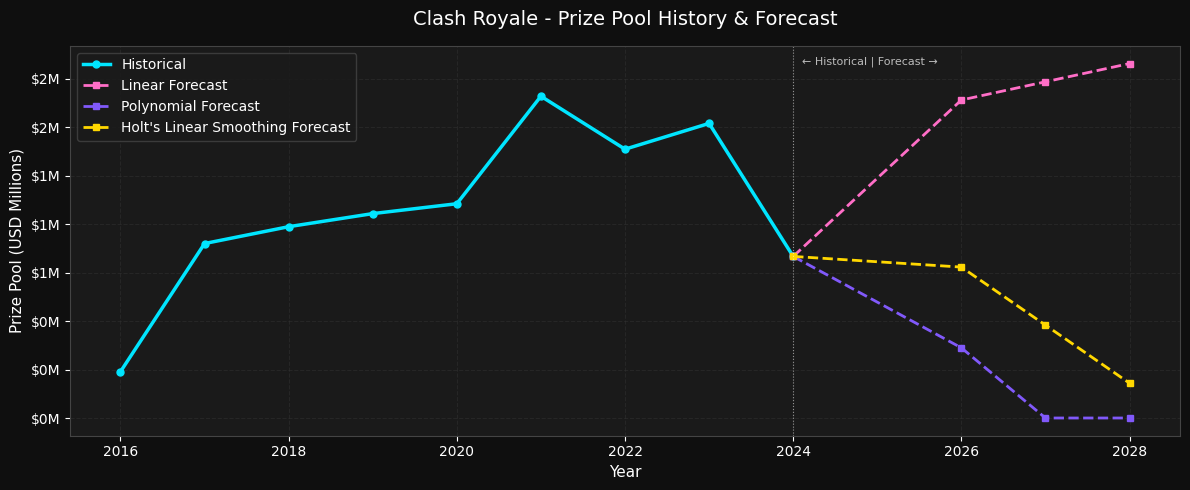

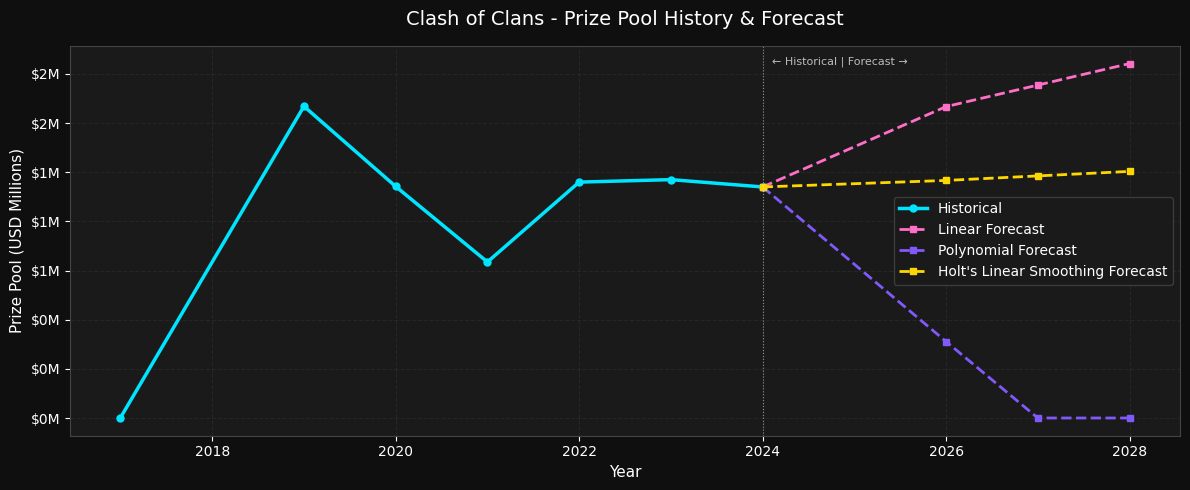

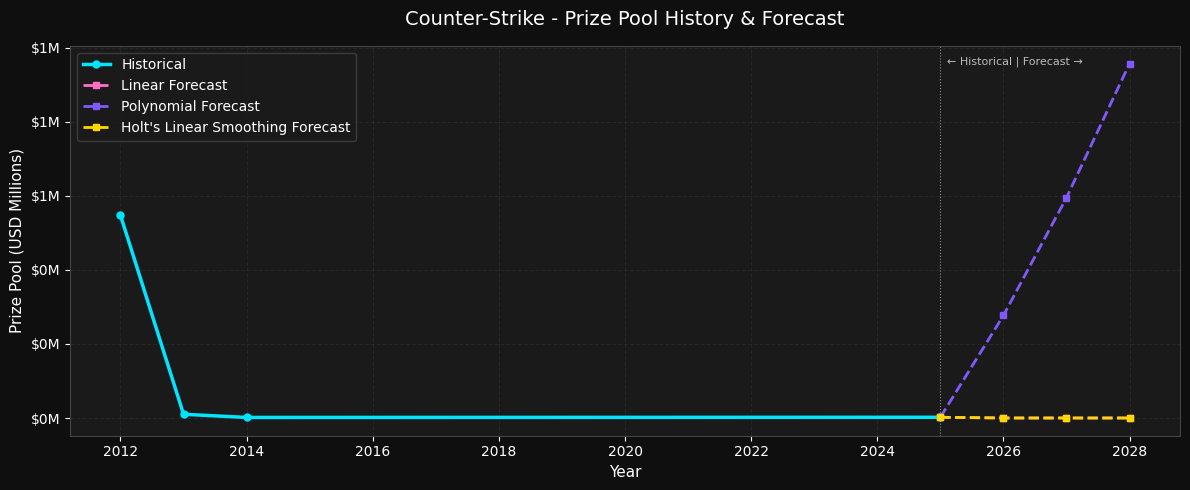

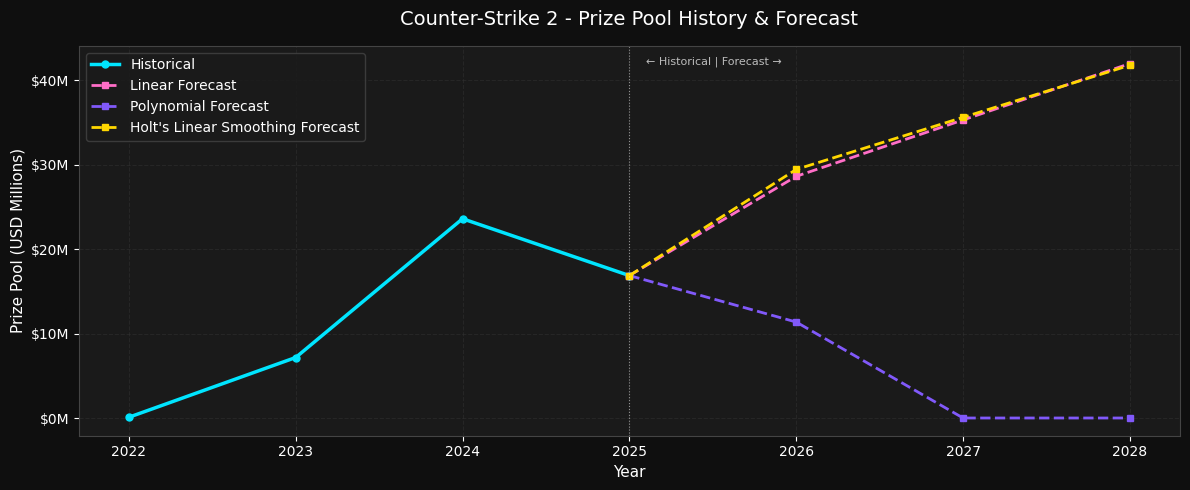

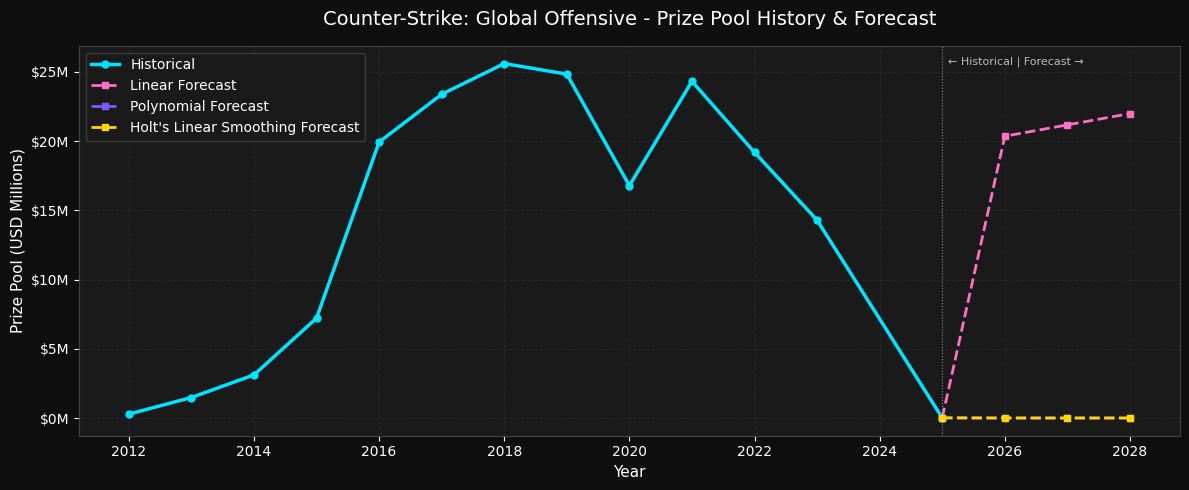

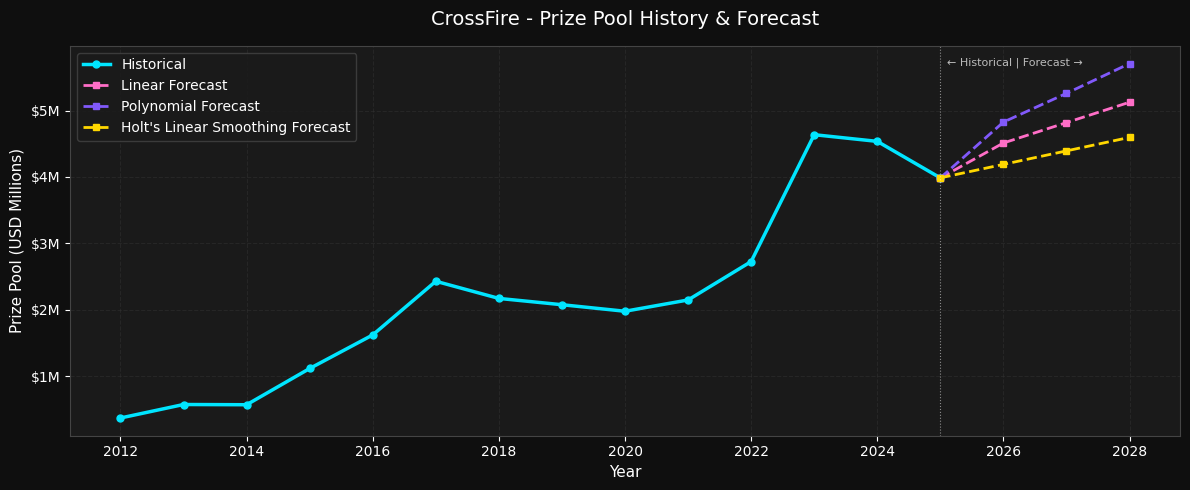

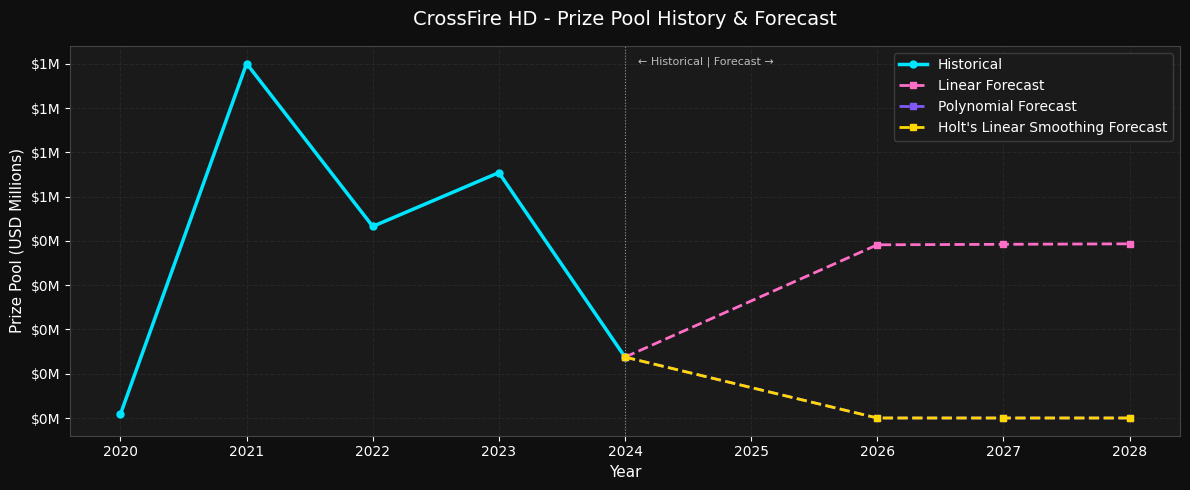

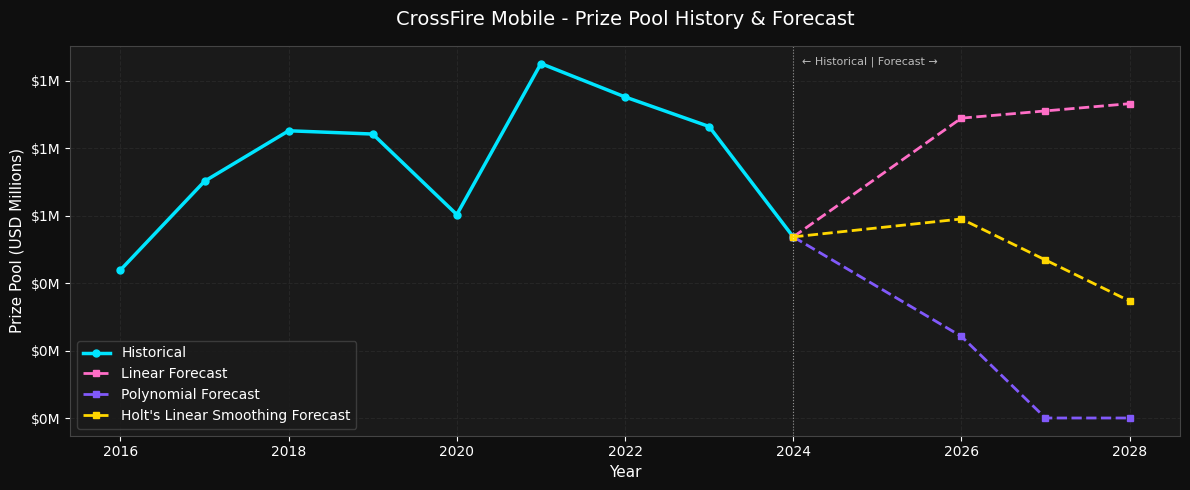

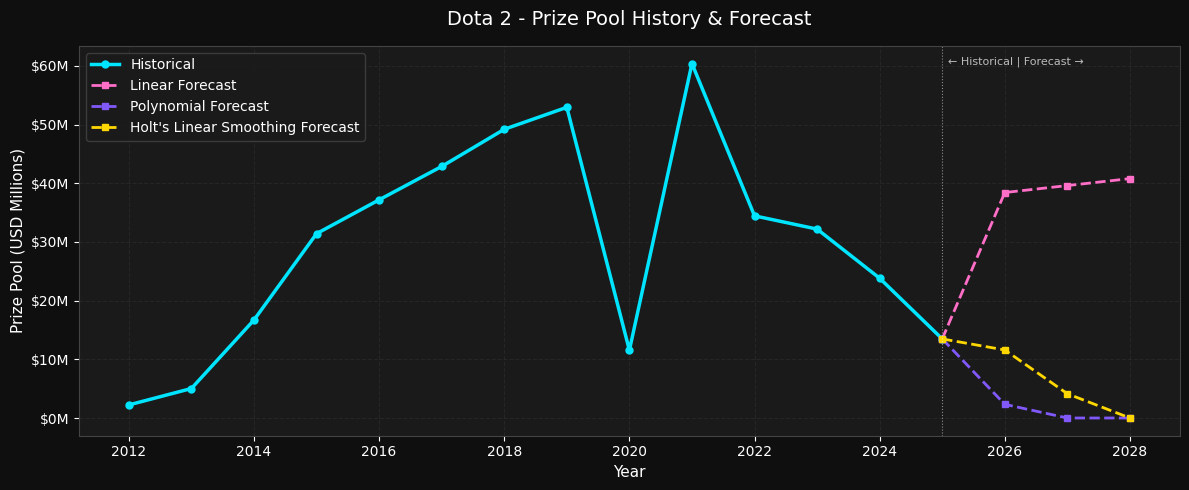

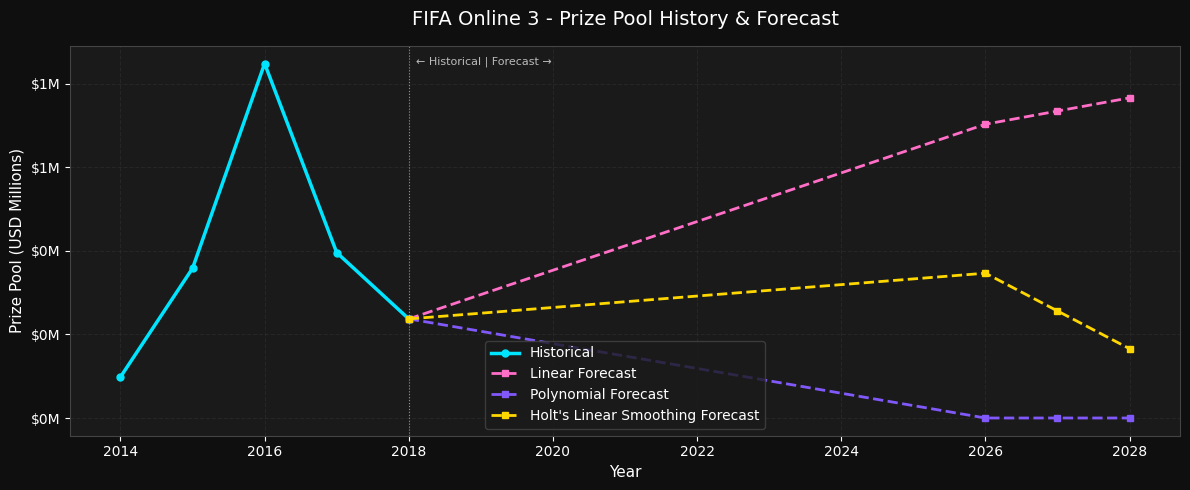

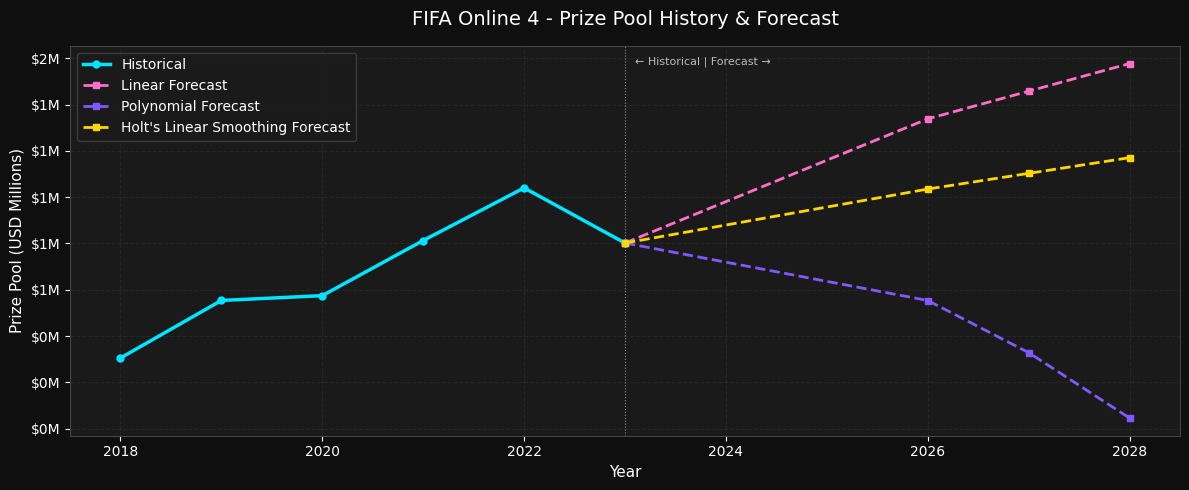

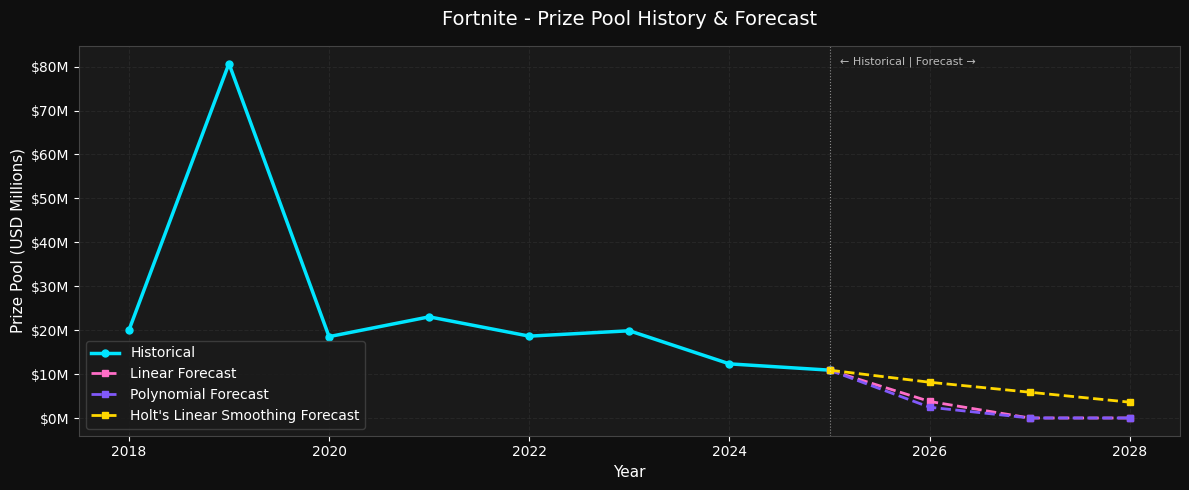

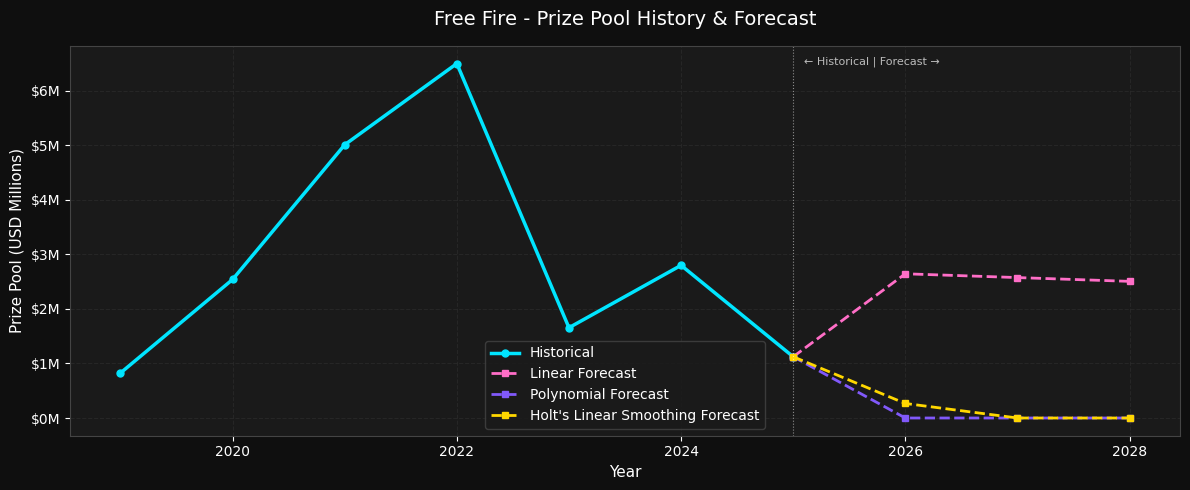

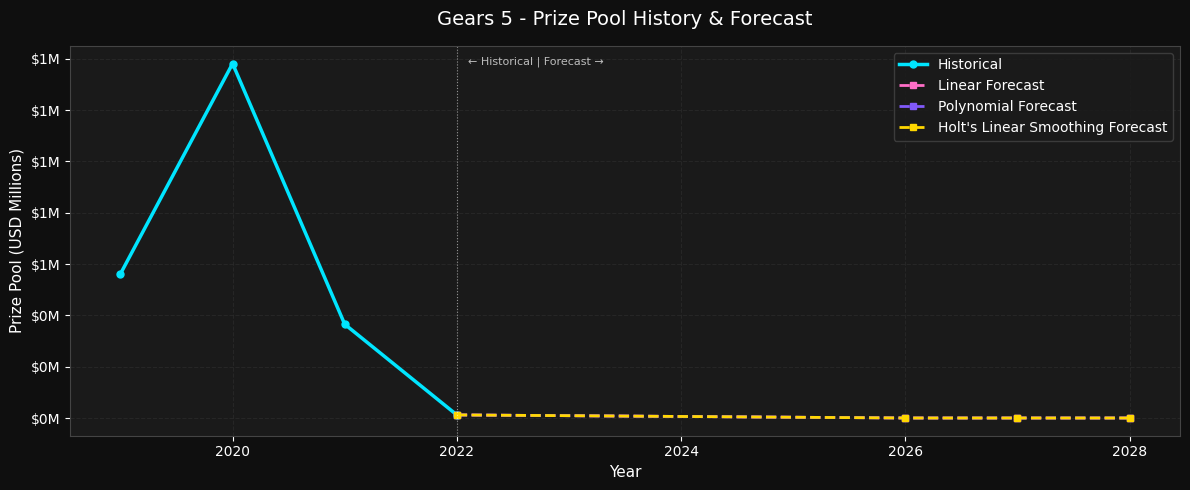

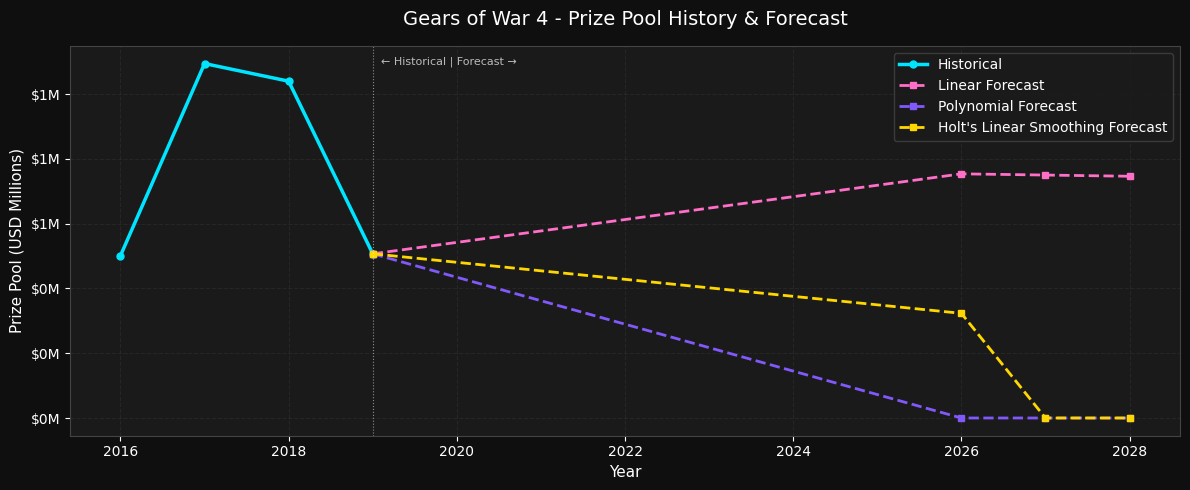

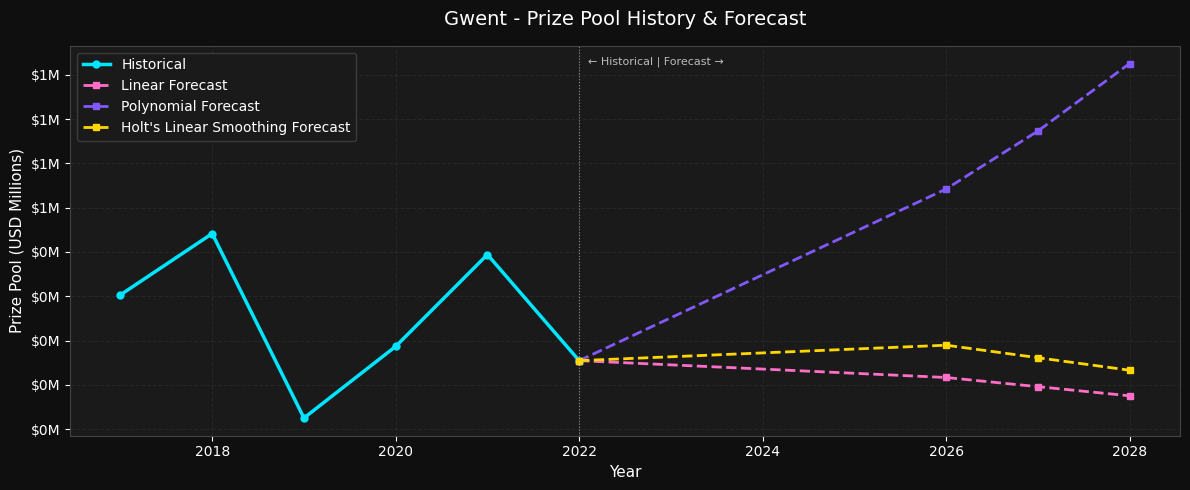

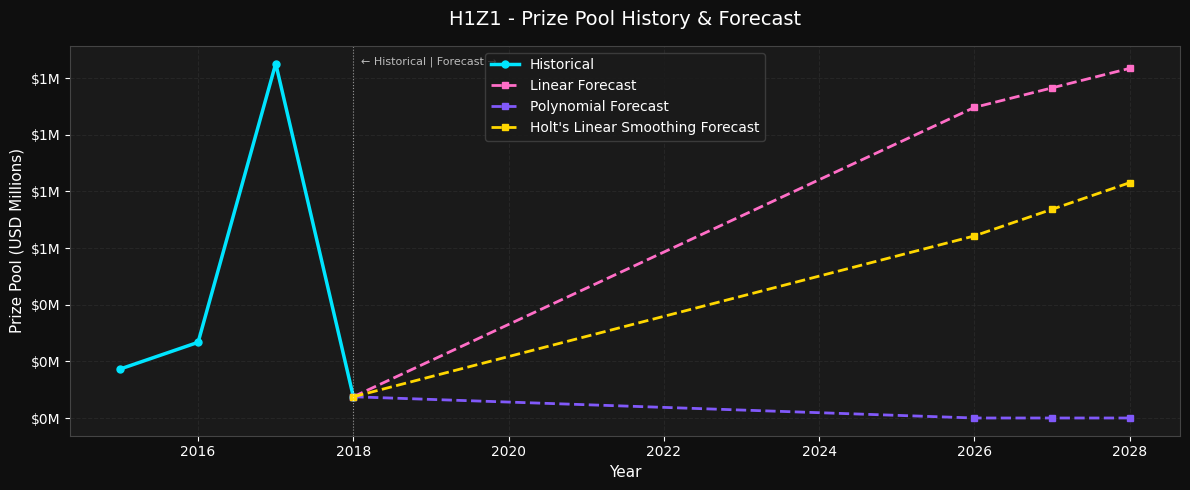

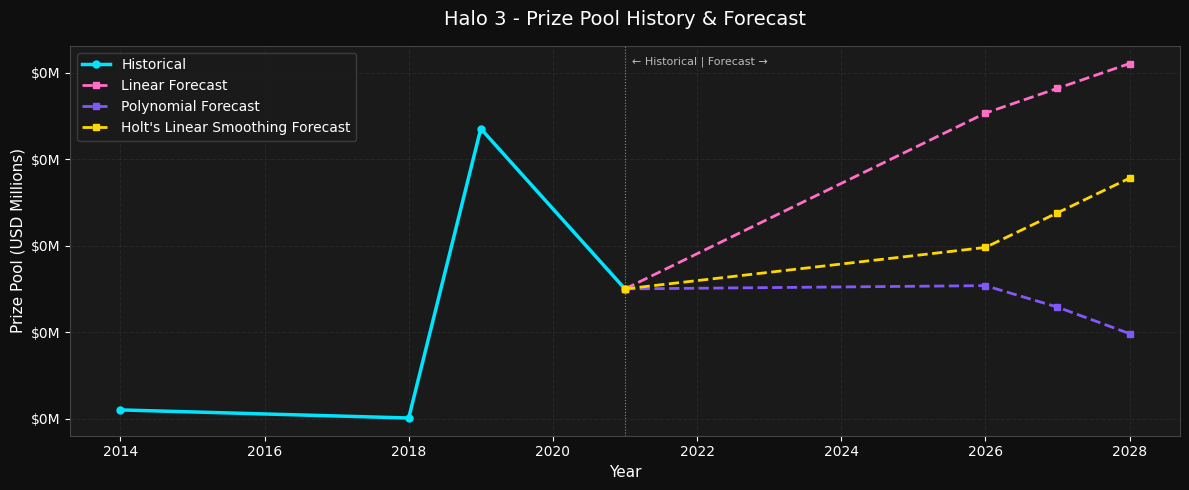

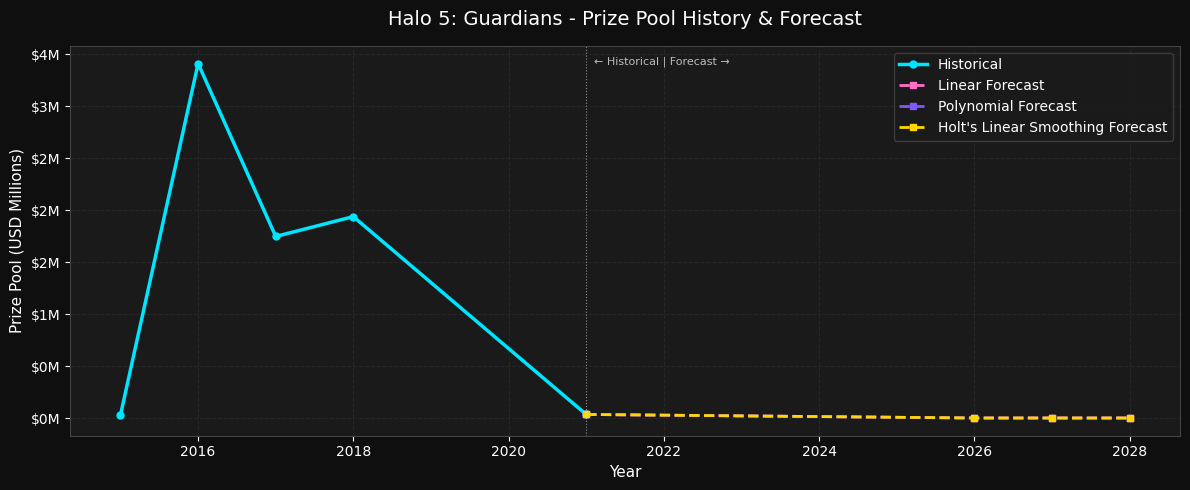

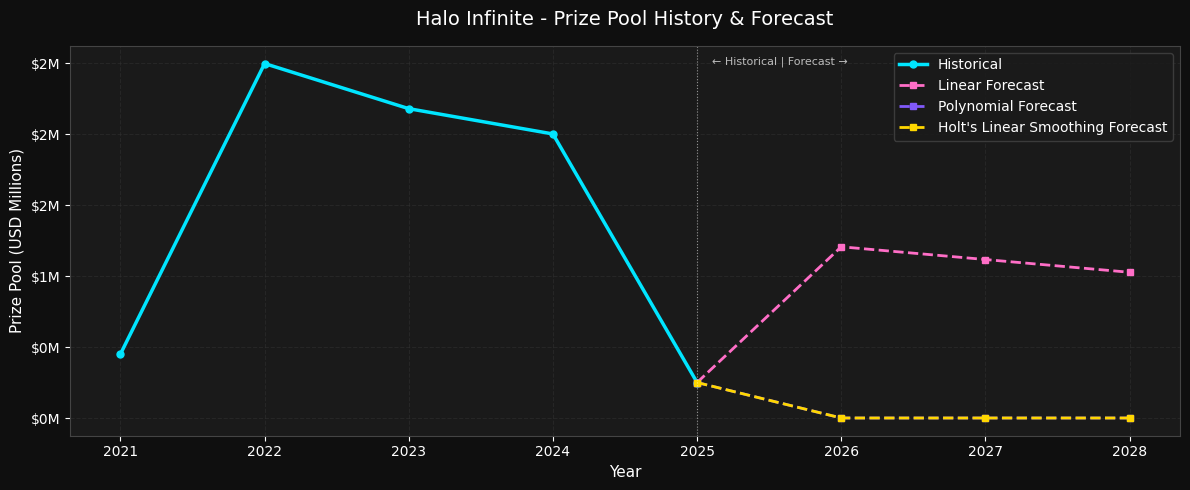

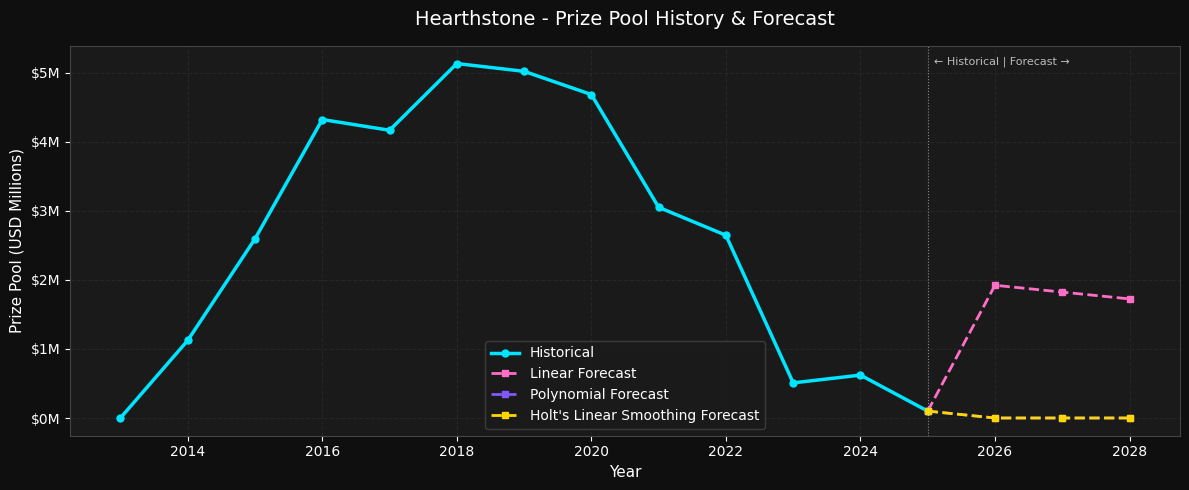

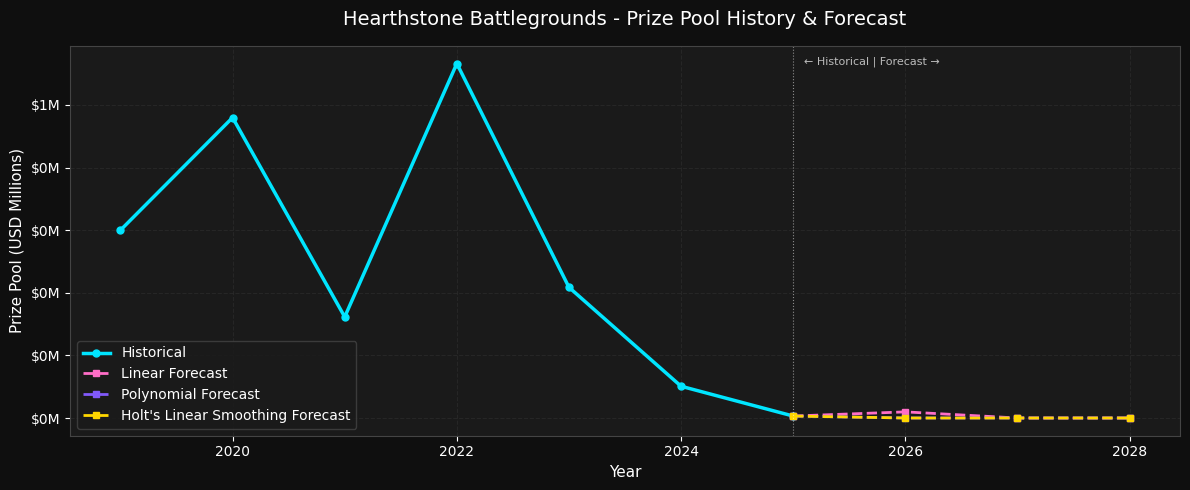

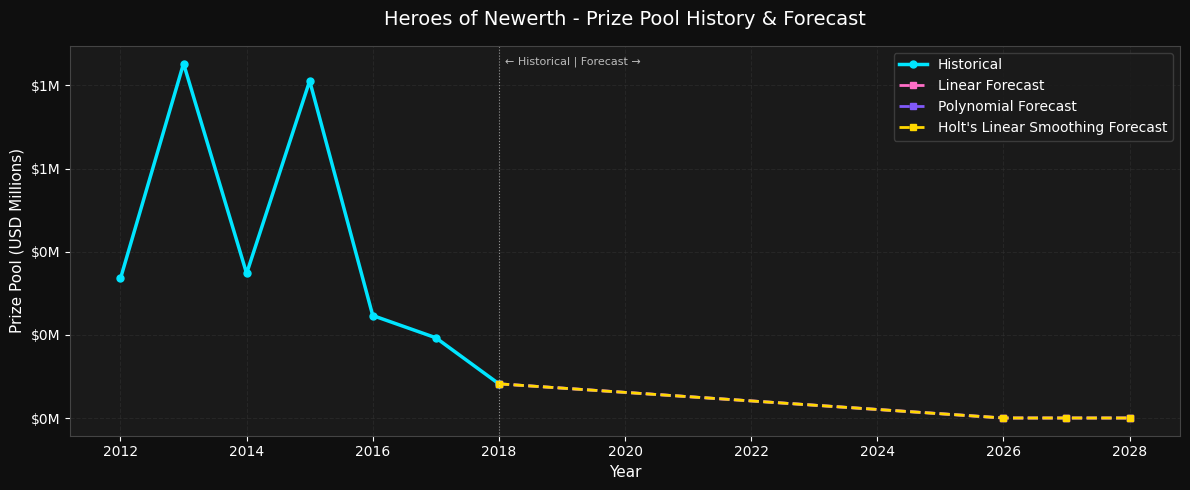

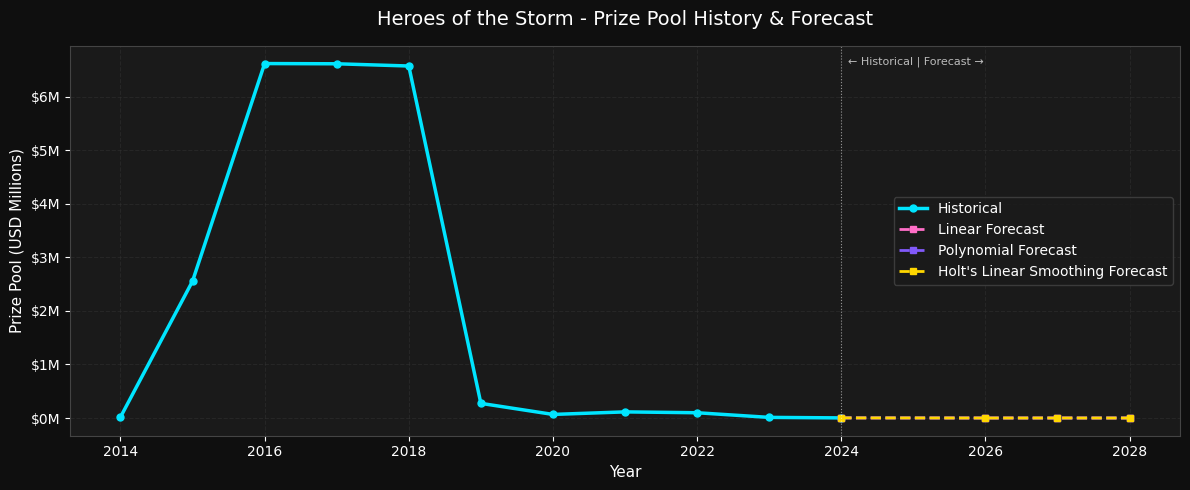

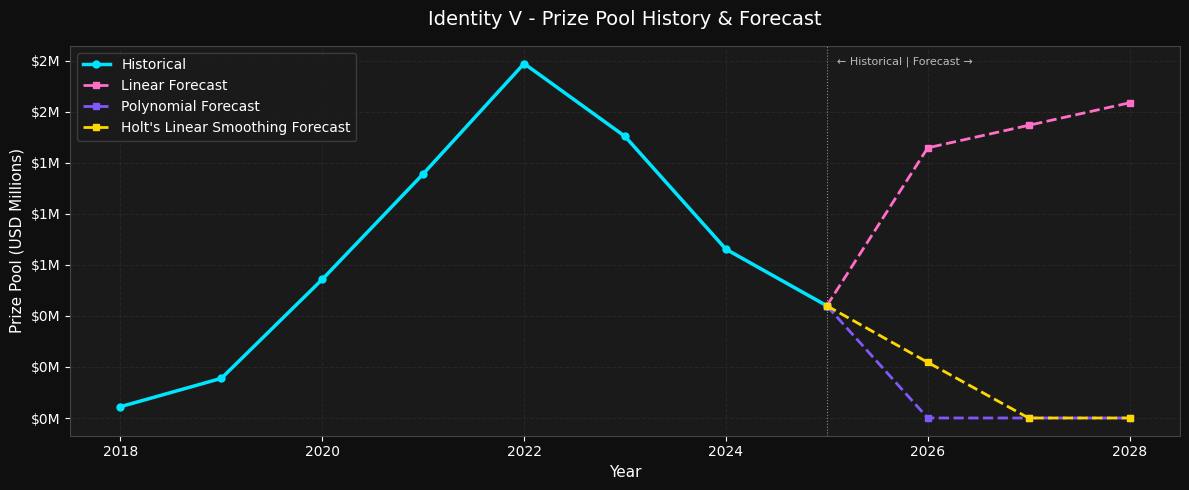

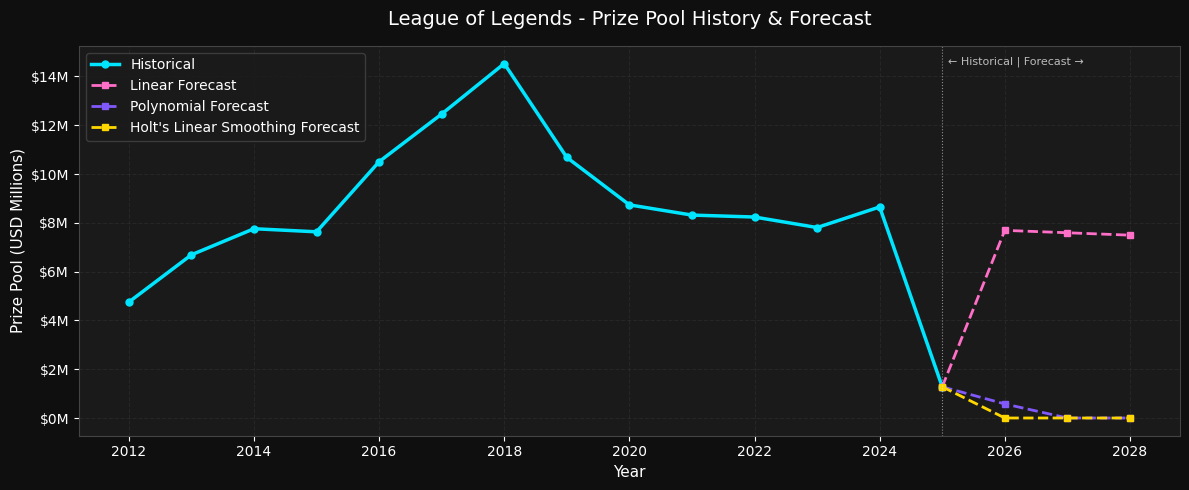

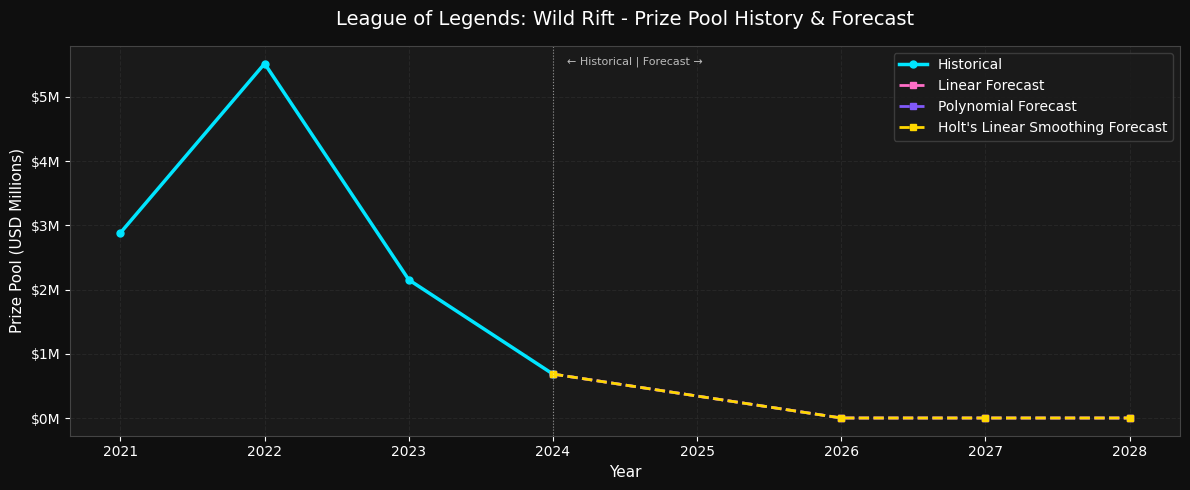

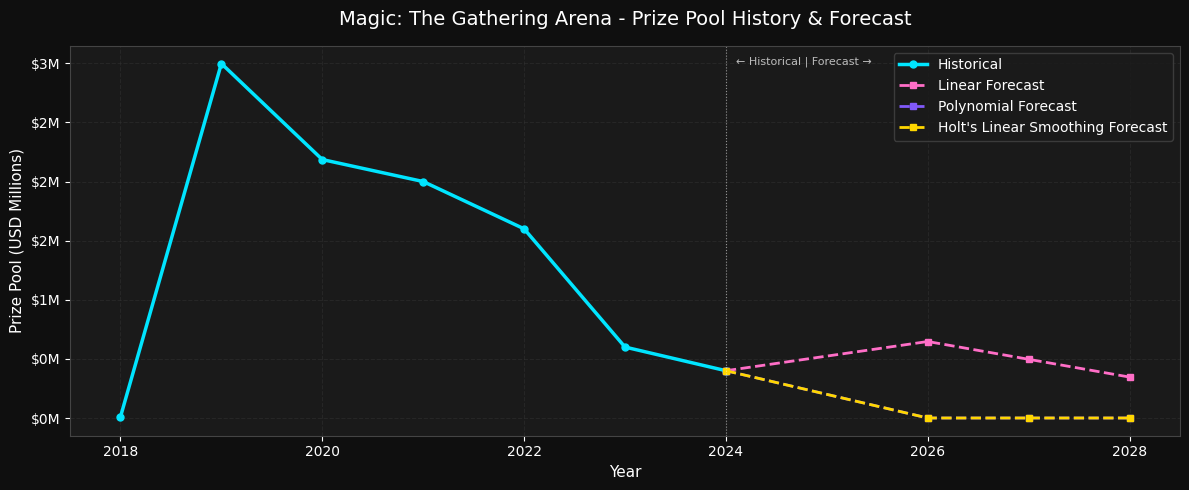

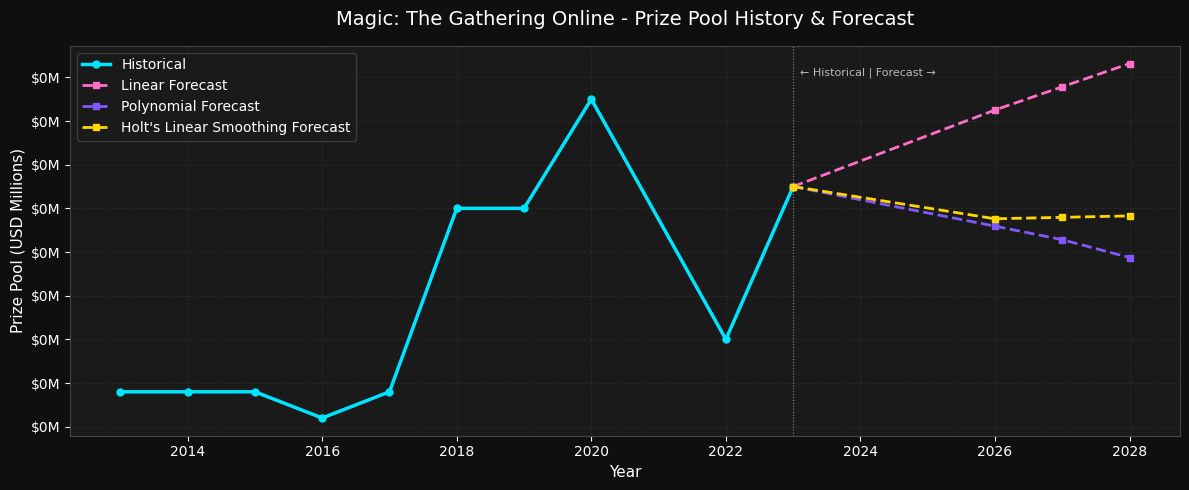

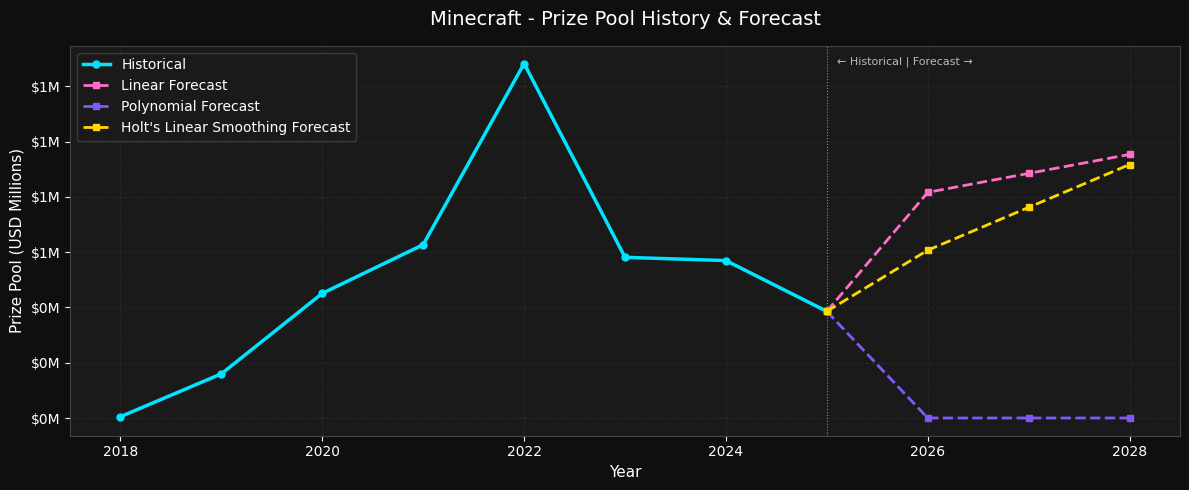

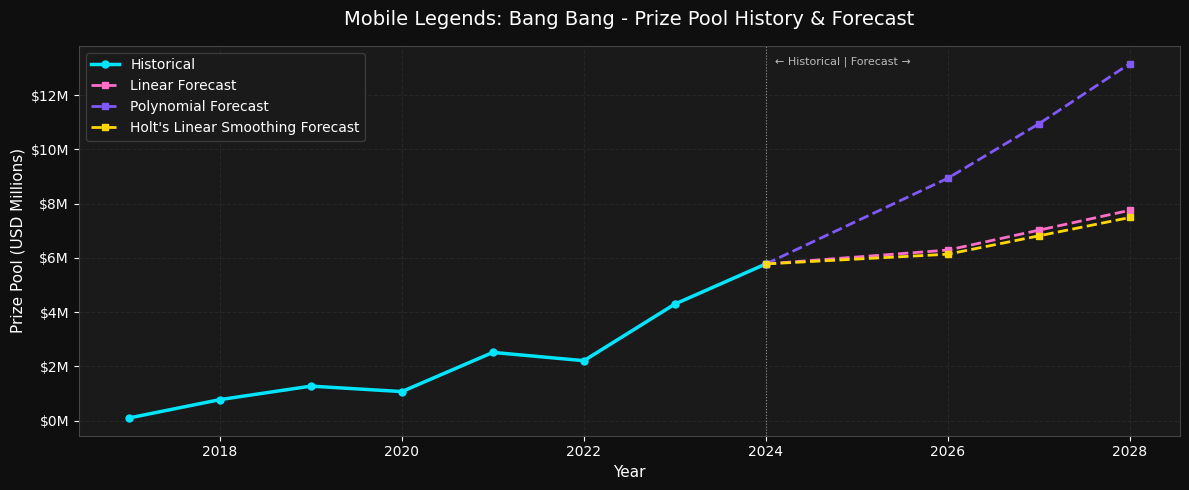

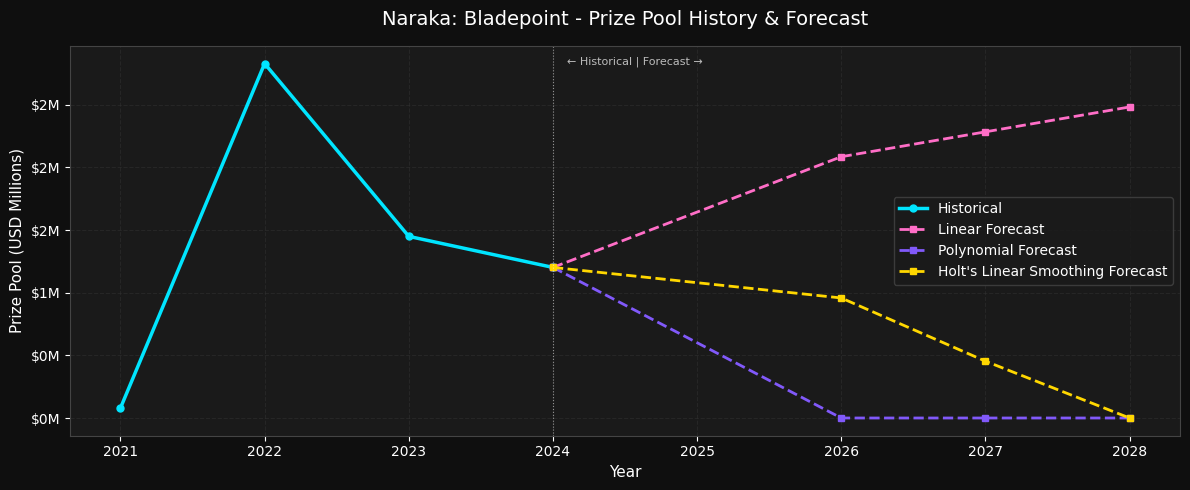

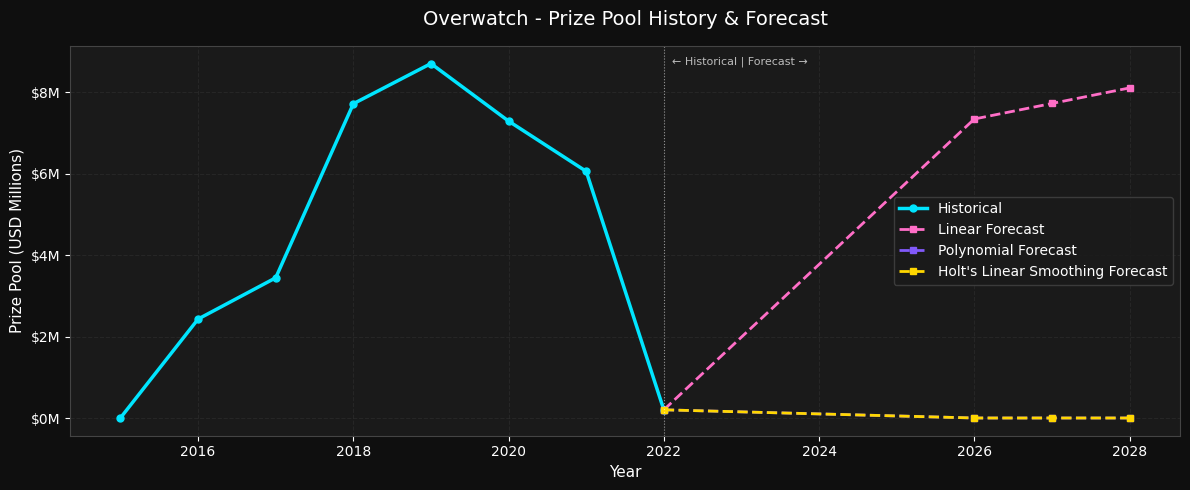

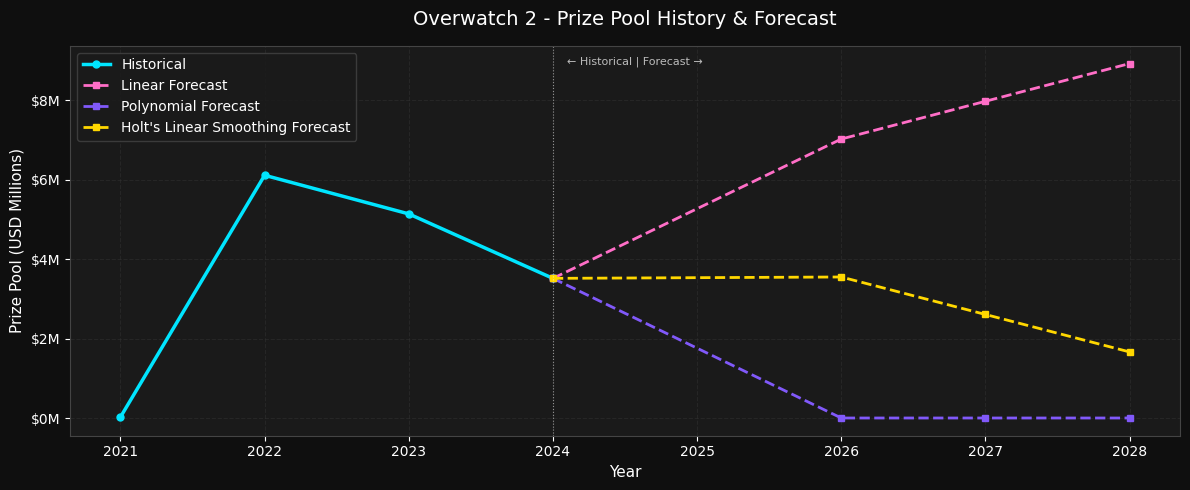

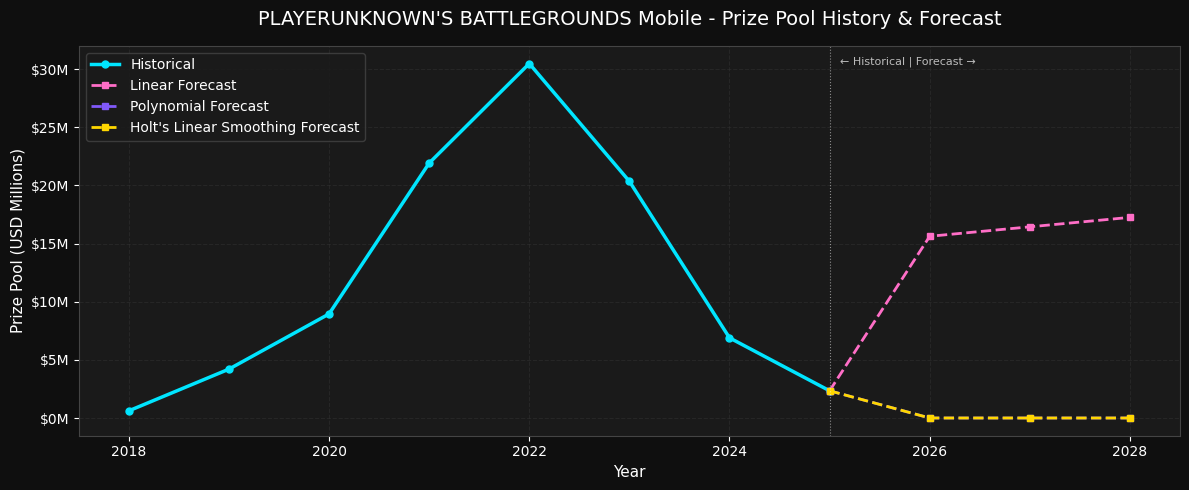

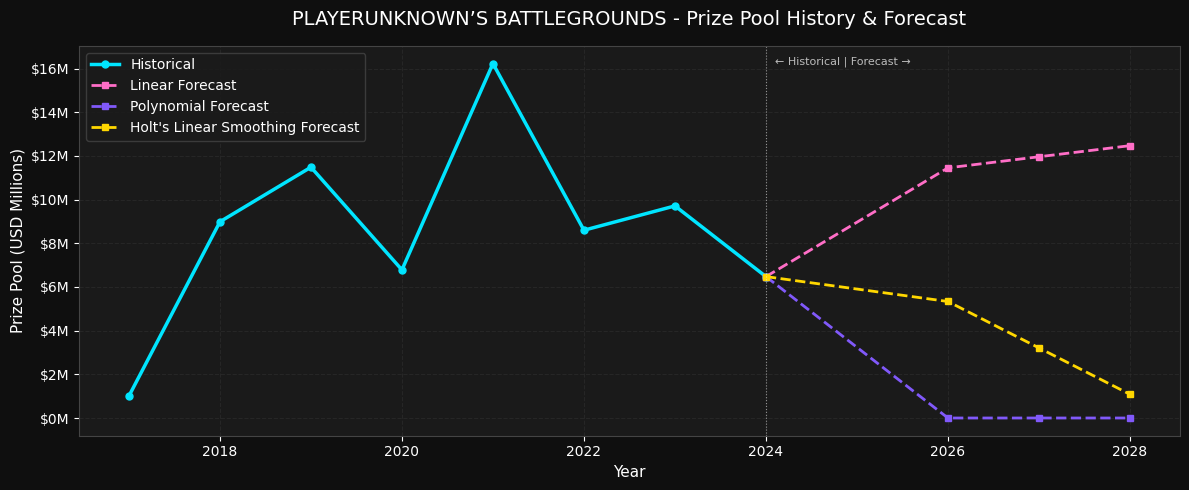

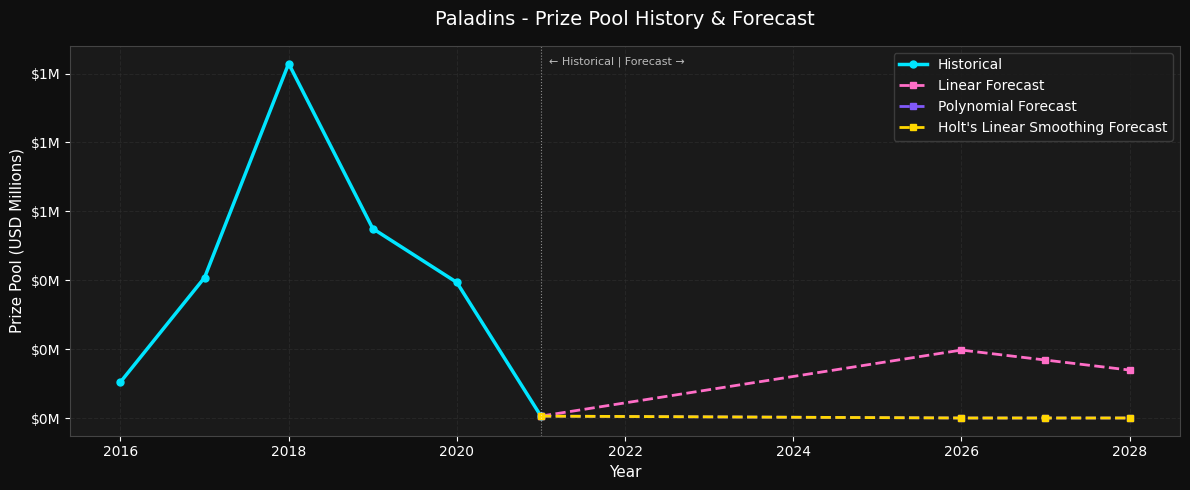

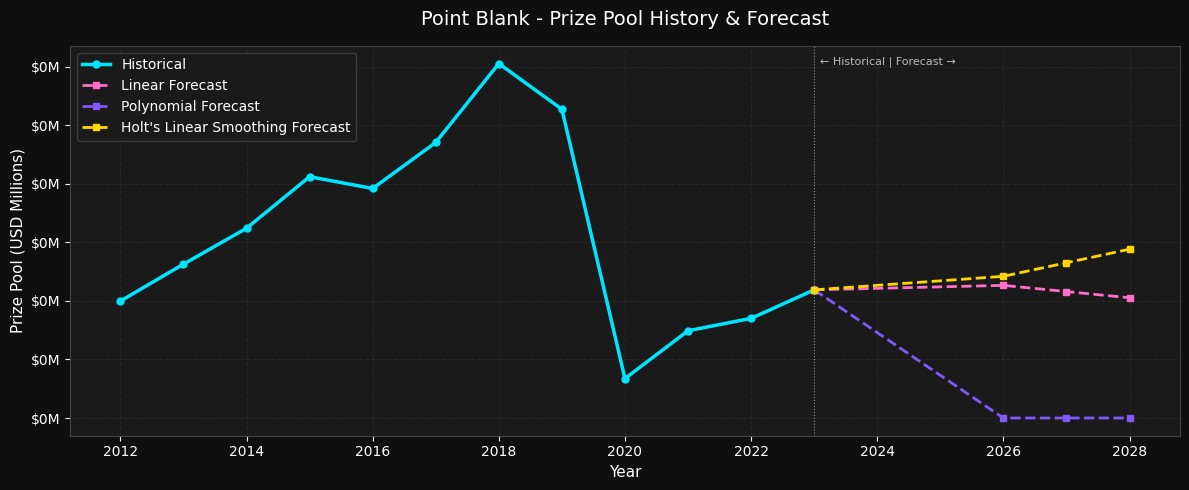

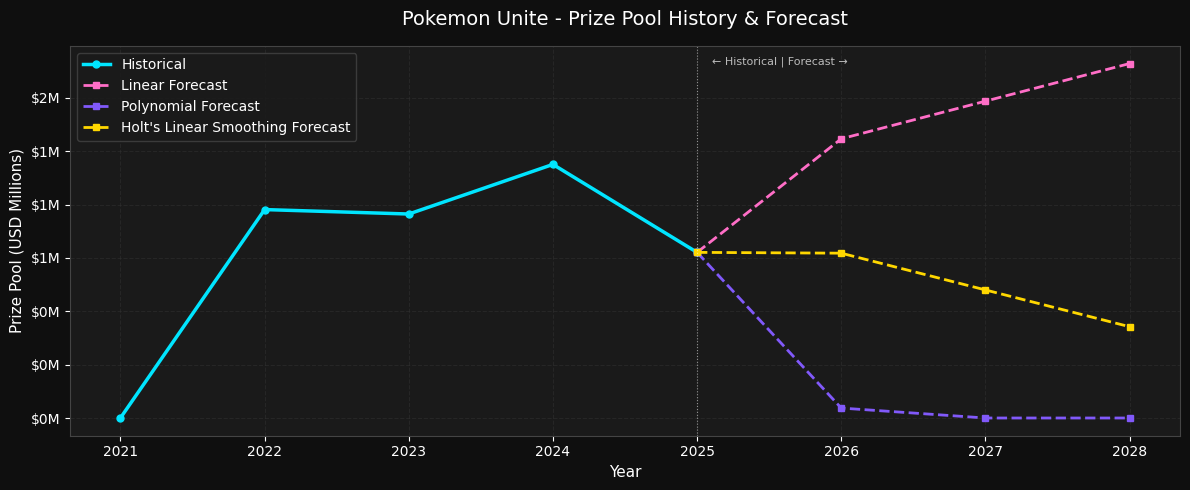

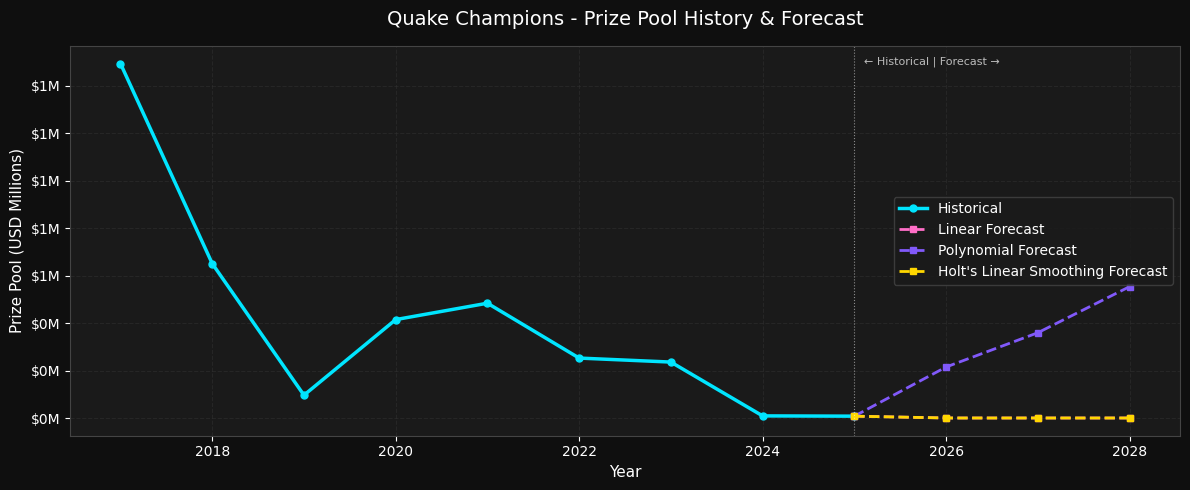

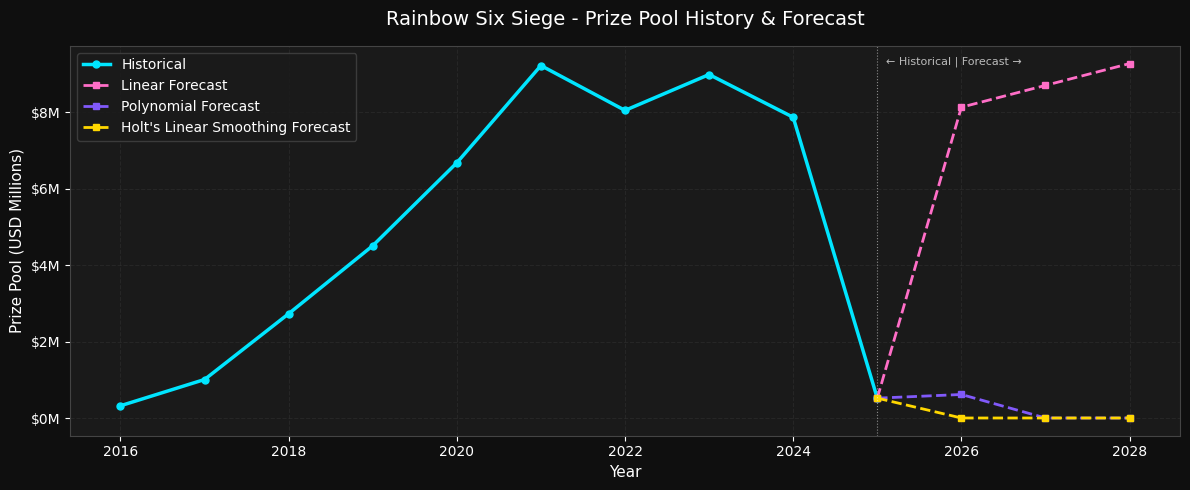

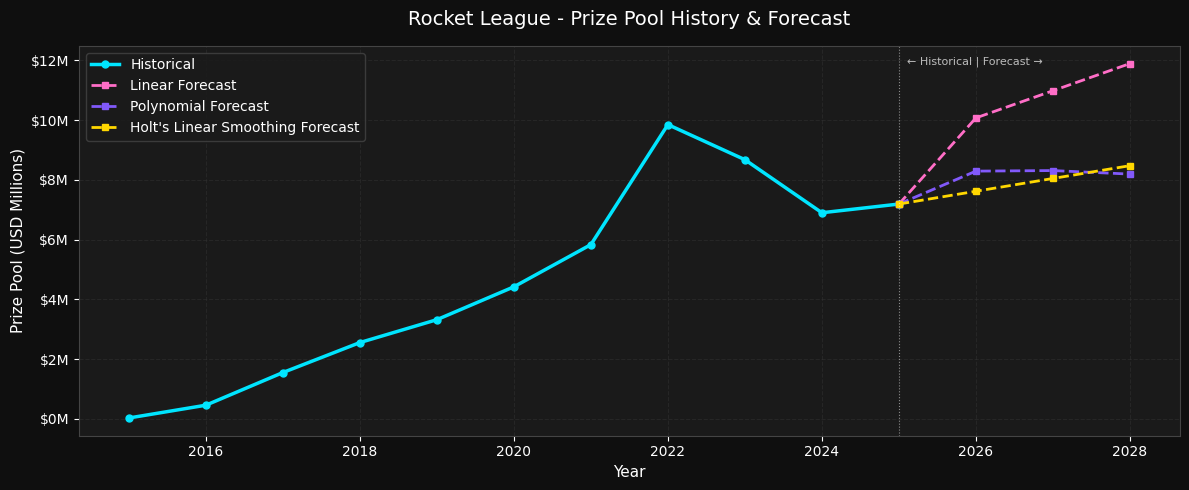

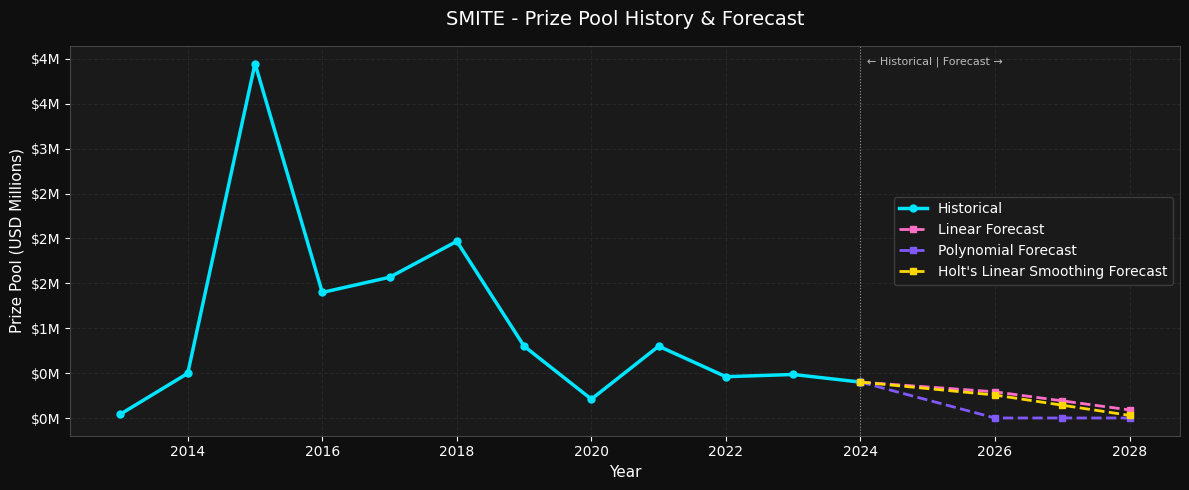

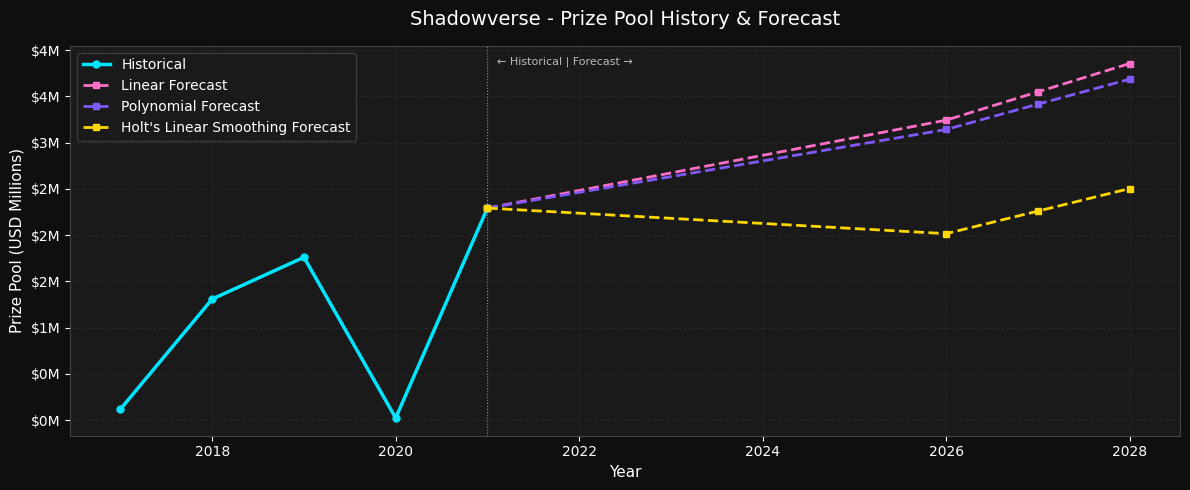

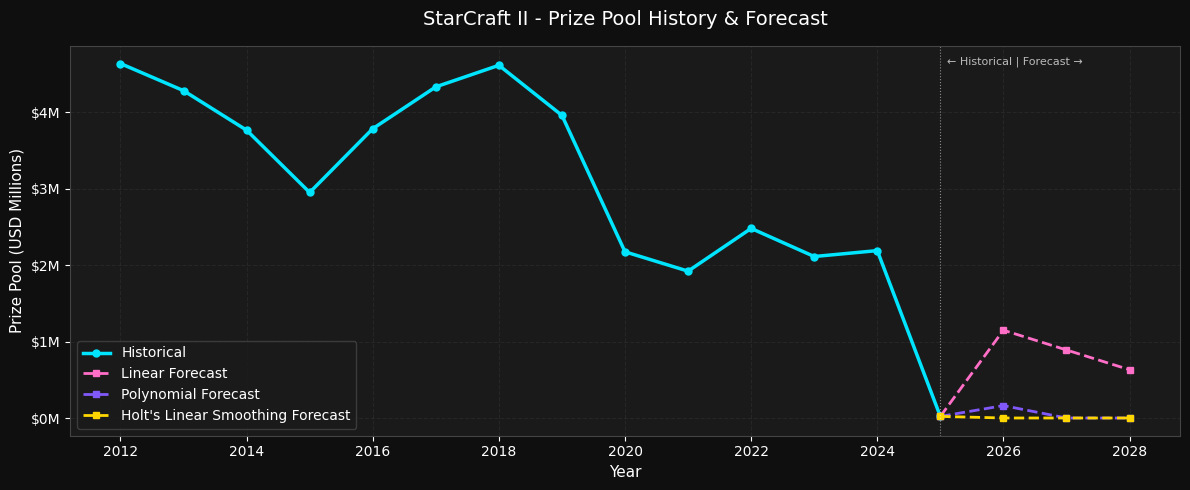

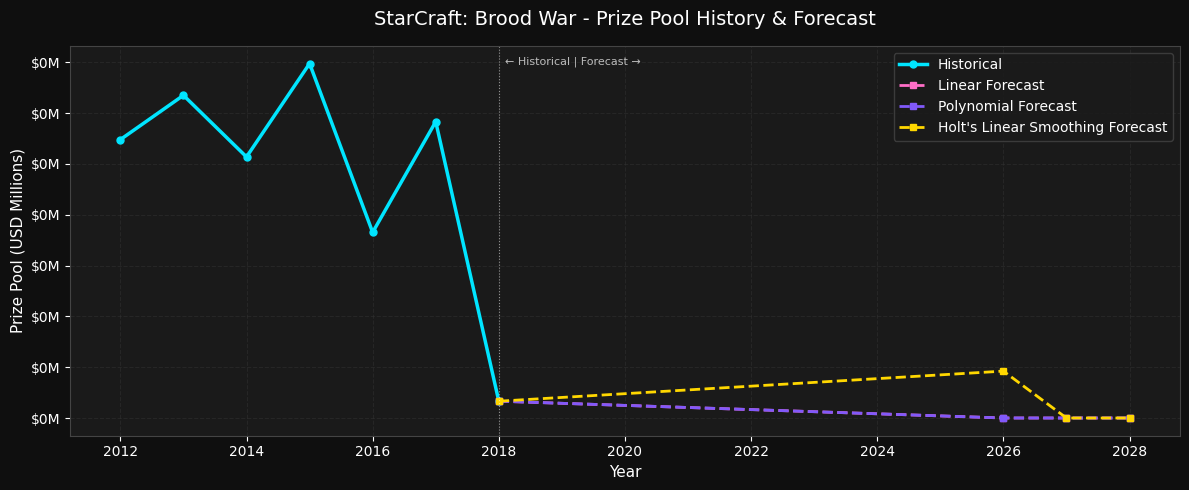

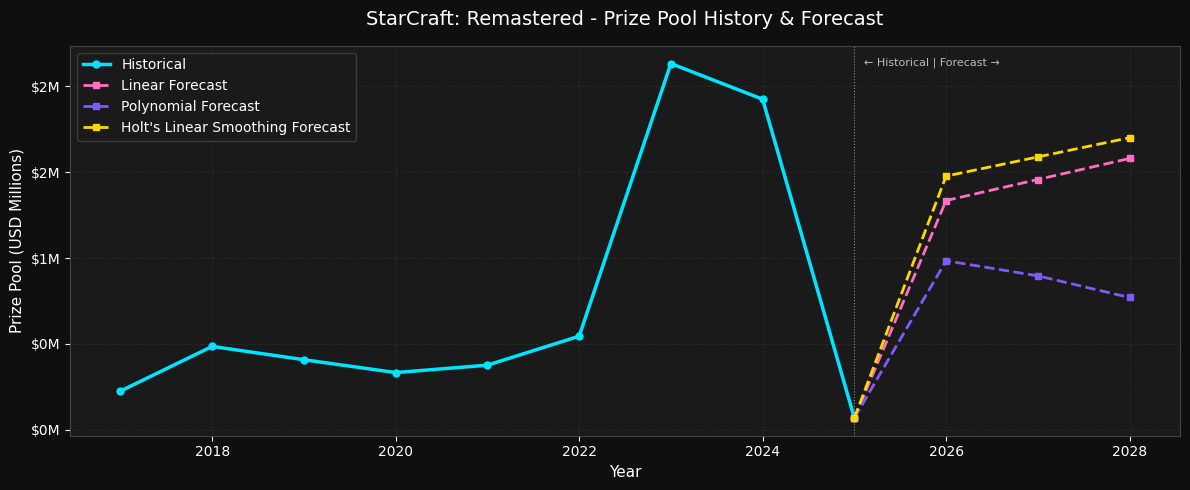

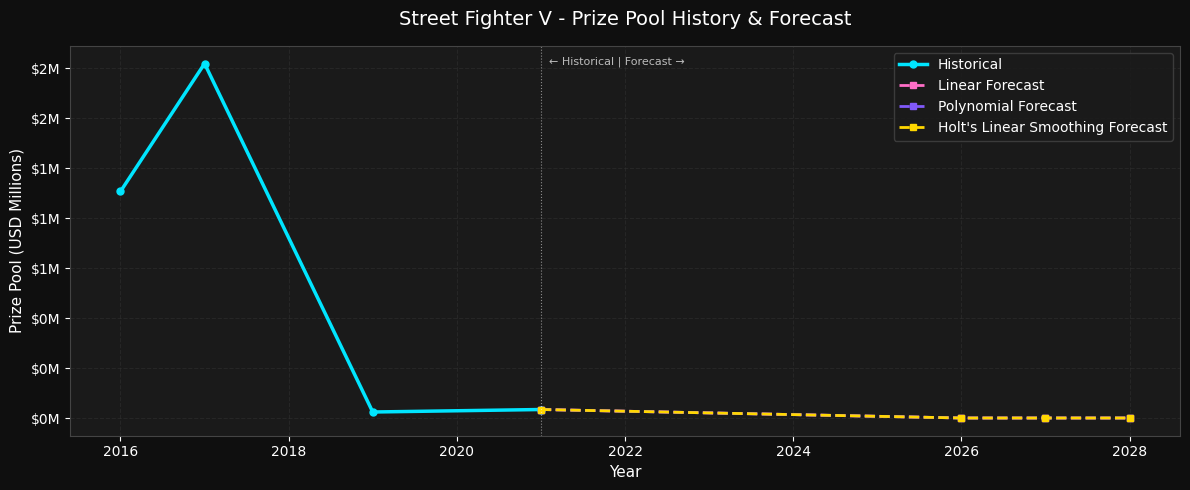

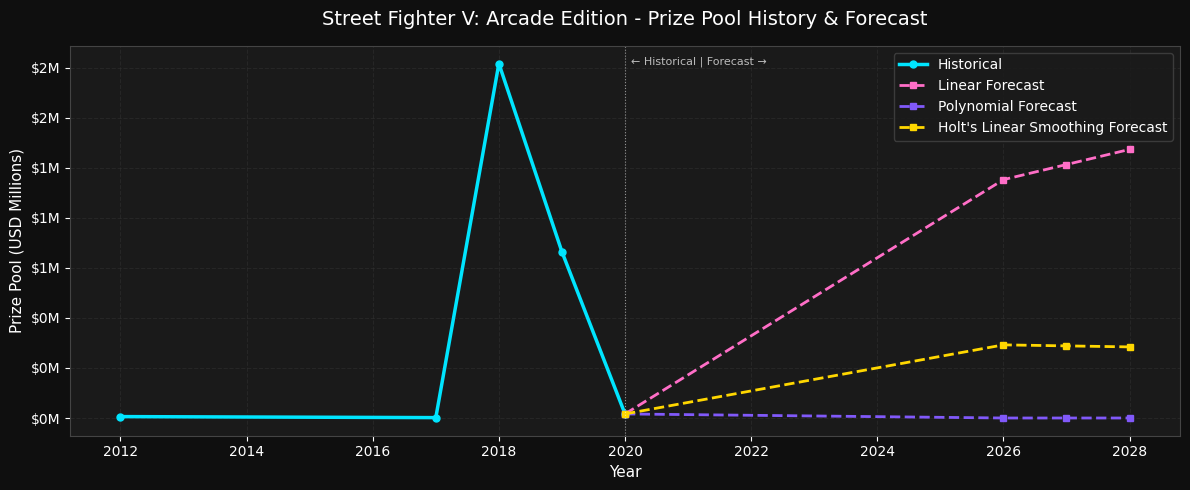

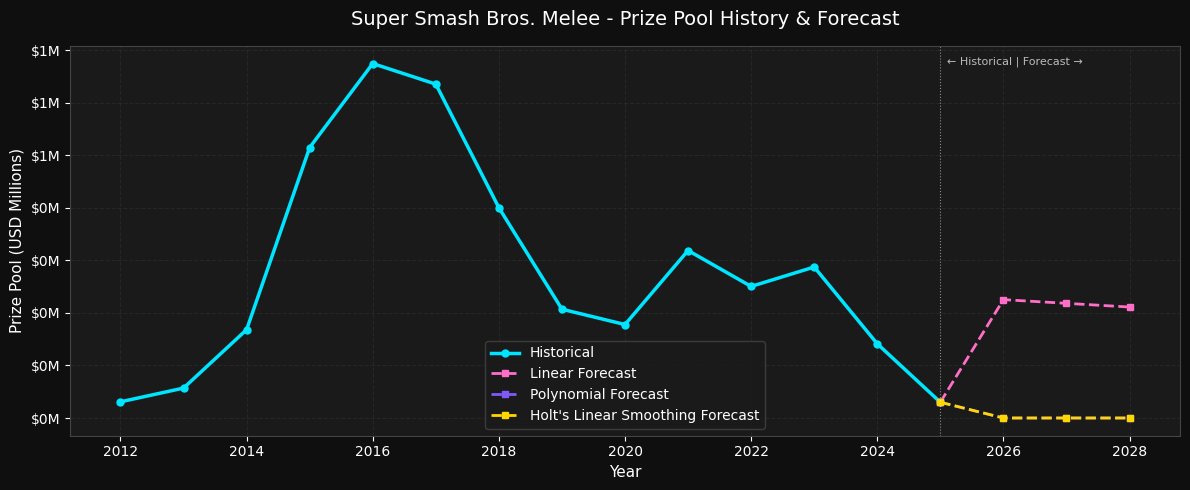

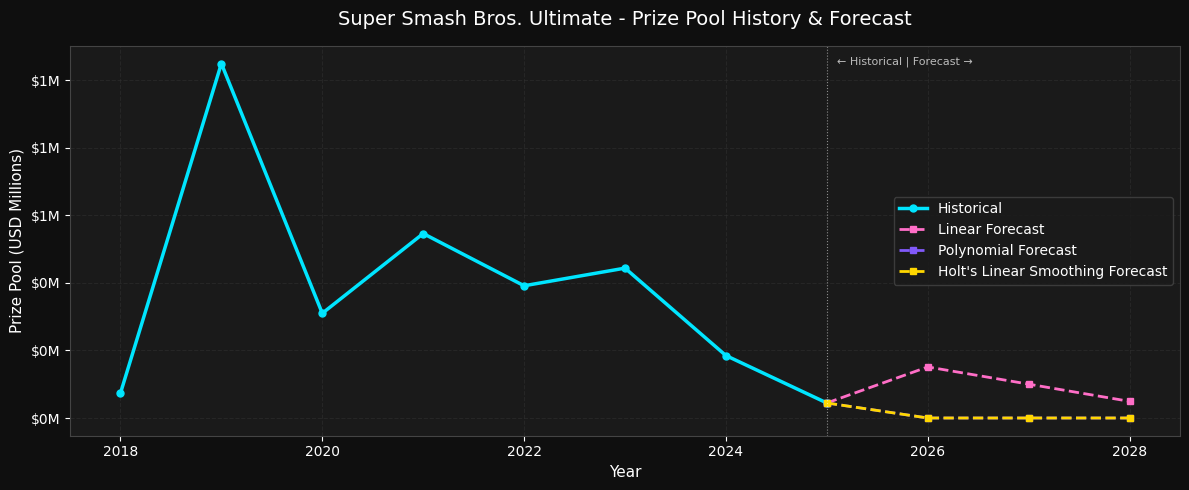

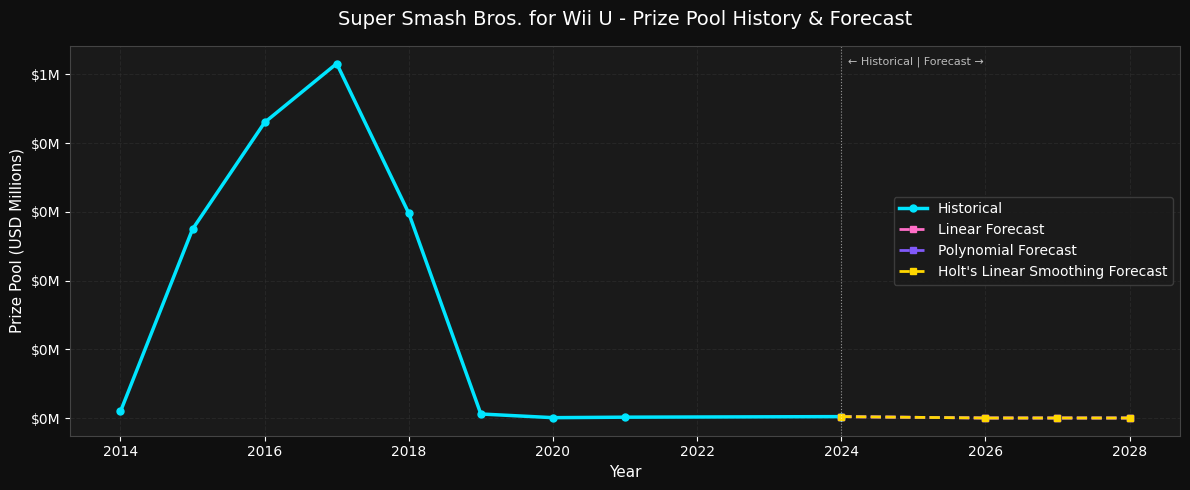

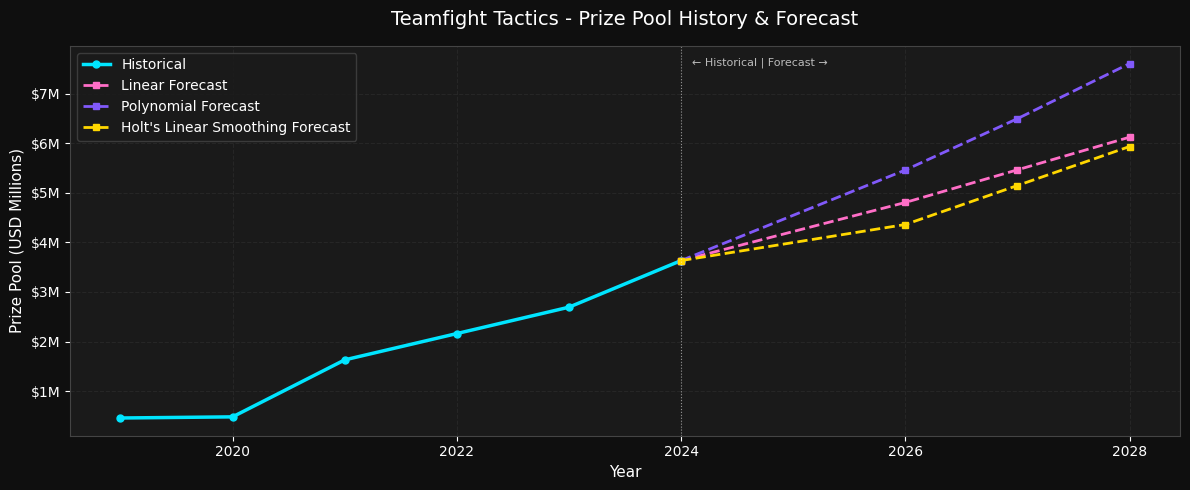

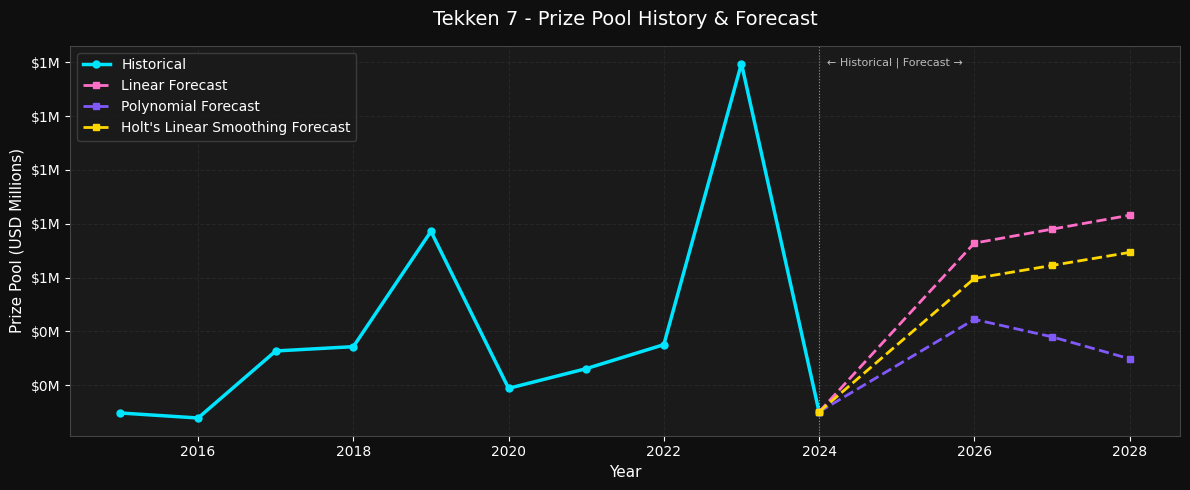

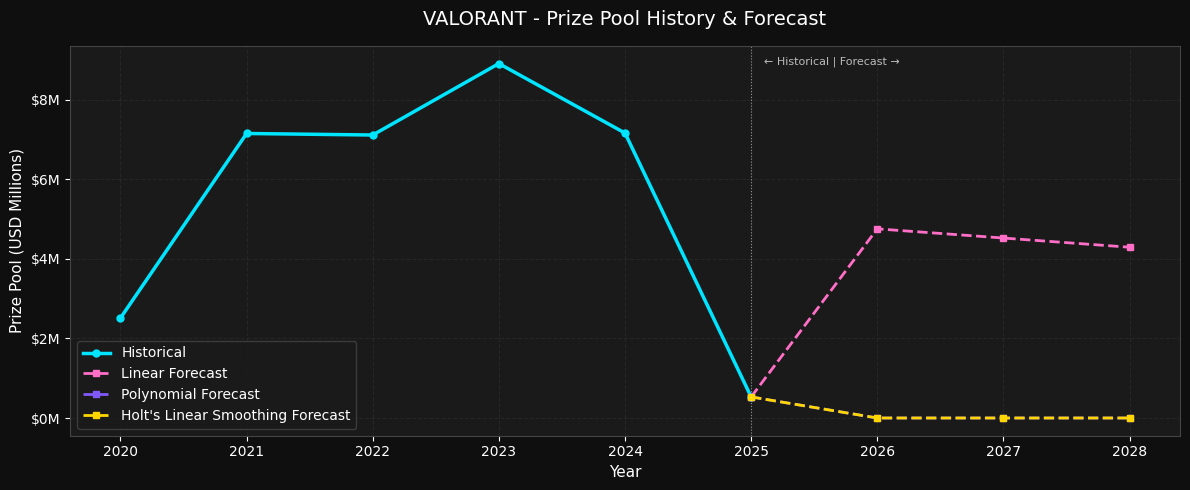

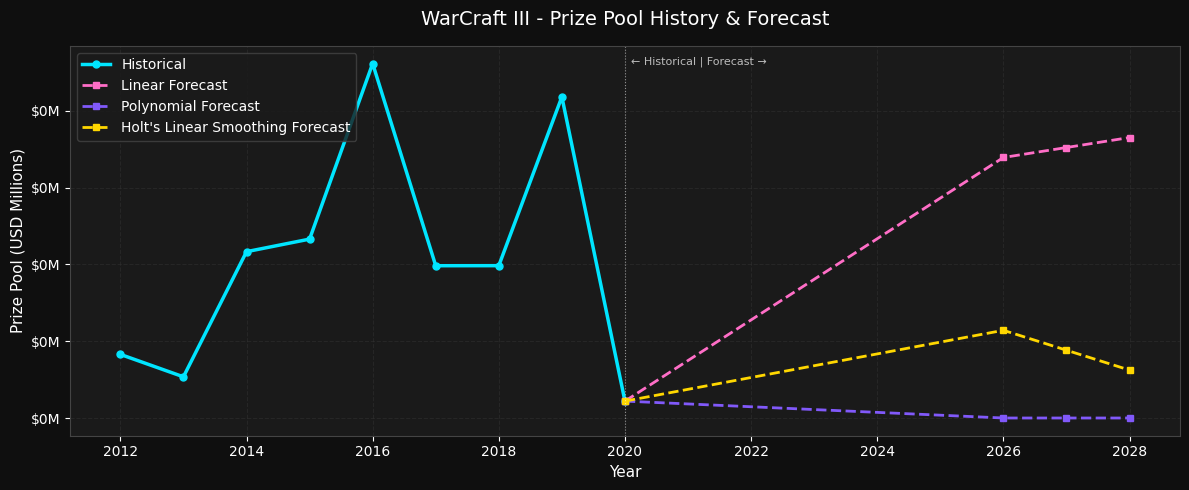

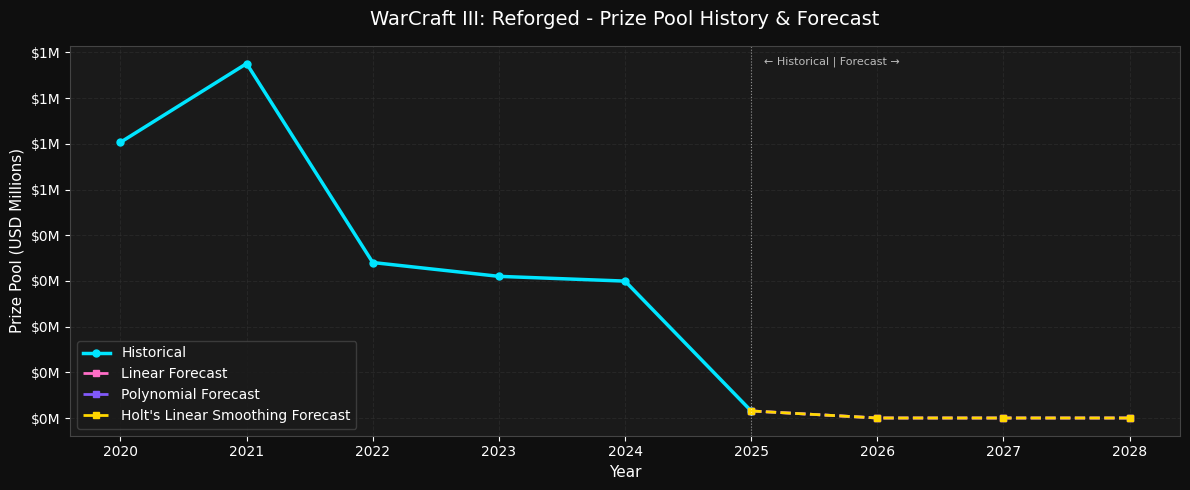

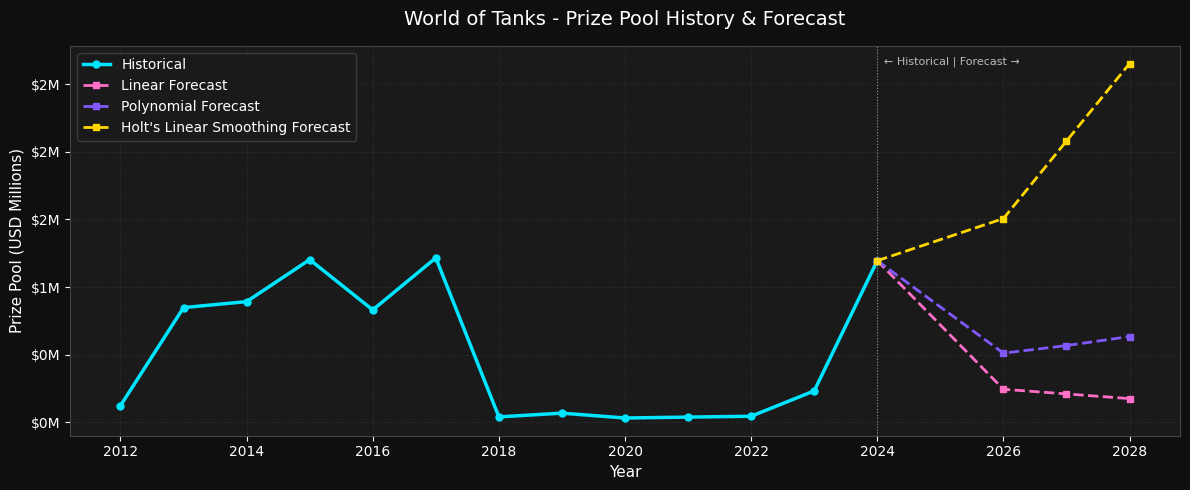

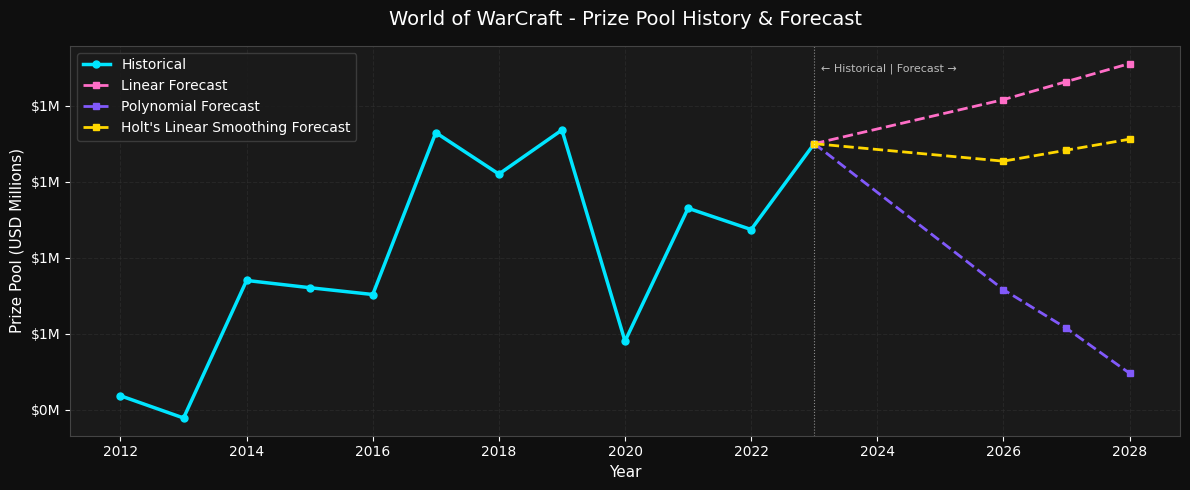

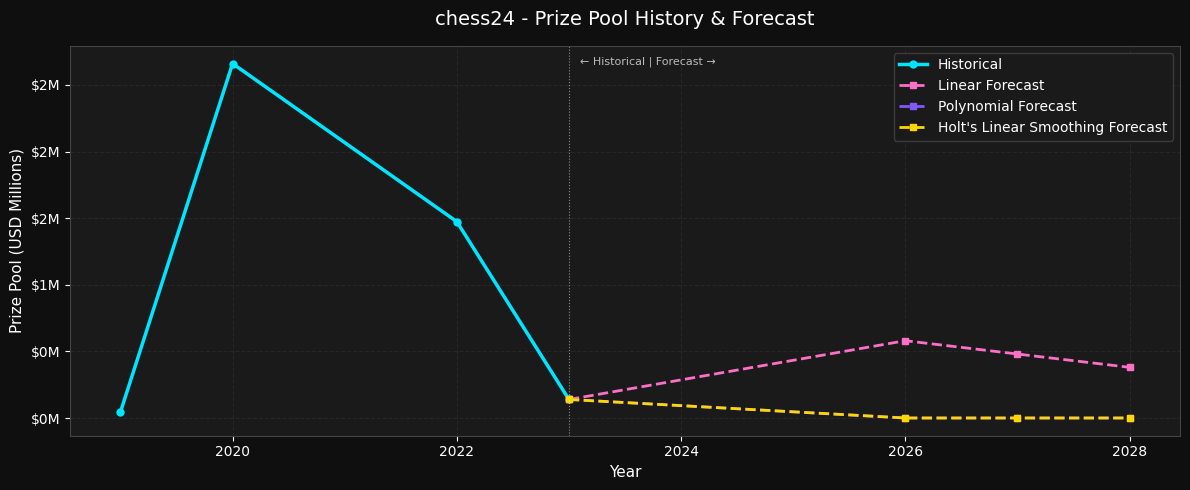

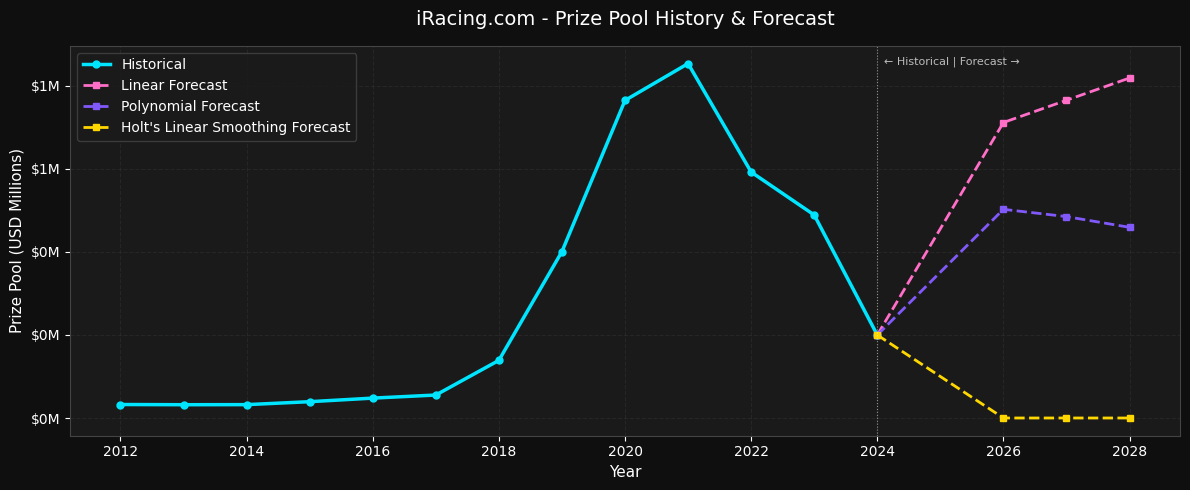

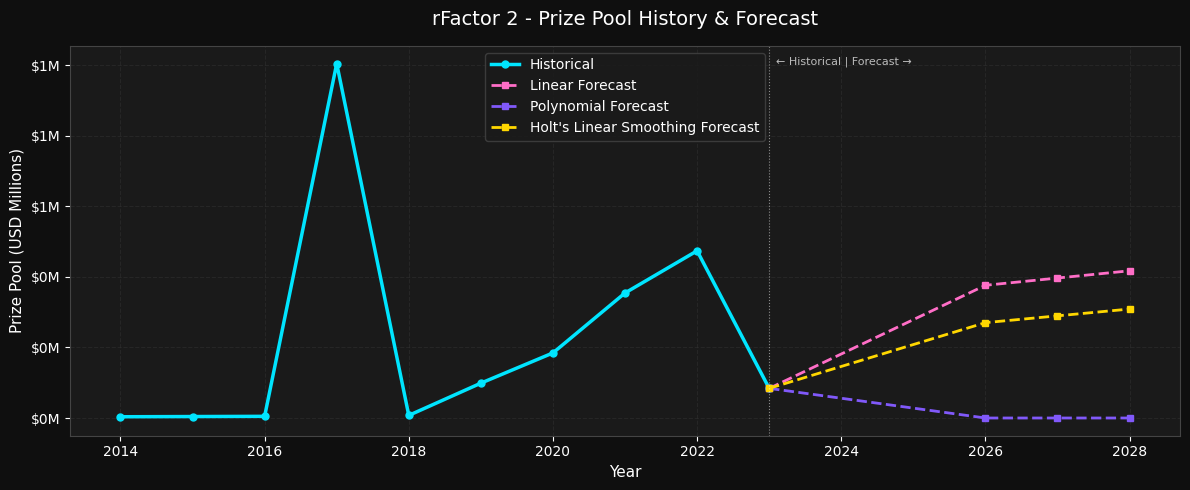

In [182]:
for game in valid_games:
    #Historical data
    history = model_data[model_data["game"] == game].sort_values("year")

    #Linear predictions
    linear = predictions_df[predictions_df["game"] == game].sort_values("year")

    #Polynomial predictions
    poly = poly_df[poly_df["game"] == game].sort_values("year")

    #Exponential predictions
    exp = exp_df[exp_df["game"] == game].sort_values("year")

    fig, ax = plt.subplots(figsize=(12,5))

    #Historical line
    ax.plot(
        history["year"], history["prize_pool_usd"] / 1_000_000,
        color = "#00e5ff", linewidth=2.5, marker="o", markersize=5, label="Historical"
    )

    #Connecting historical data to predictions with a dotted bridge line
    last_hist_year = history["year"].iloc[-1]
    last_hist_value = history["prize_pool_usd"].iloc[-1] / 1_000_000

    #Linear prediction line
    linear_years = [last_hist_year] + linear["year"].tolist()
    linear_values = [last_hist_value] + (linear["predicted_prize_pool"]/1_000_000).tolist()
    ax.plot(linear_years, linear_values, color ="#ff6ec7", linewidth = 2,
            linestyle = "--", marker="s", markersize=5, label = "Linear Forecast")

    #Polynomial prediction line
    poly_years = [last_hist_year] + poly["year"].tolist()
    poly_values = [last_hist_value] + (poly["predicted_prize_pool"]/1_000_000).tolist()
    ax.plot(poly_years, poly_values, color ="#8159fa", linewidth = 2,
            linestyle = "--", marker="s", markersize=5, label = "Polynomial Forecast")

    #Exponential prediction line
    exp_years = [last_hist_year] + exp["year"].tolist()
    exp_values = [last_hist_value] + (exp["predicted_prize_pool"]/1_000_000).tolist()
    ax.plot(exp_years, exp_values, color ="#ffd700", linewidth = 2,
            linestyle = "--", marker="s", markersize=5, label = "Holt's Linear Smoothing Forecast")
    
    #Vertical line separating historical from forecast
    ax.axvline(x=last_hist_year, color = "white", linewidth=0.8, 
               linestyle = ":", alpha = 0.5)
    ax.text(last_hist_year + 0.1, ax.get_ylim()[1]*0.95, 
            "← Historical | Forecast →", color="white", fontsize=8, alpha=0.7)

    ax.set_title(f"{game} - Prize Pool History & Forecast", fontsize=14, pad=15)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Prize Pool (USD Millions)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
    ax.legend(facecolor = "#1a1a1a", edgecolor="#444444", labelcolor="white")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

#### Chart B - Combined forecast comparison (2028 only)

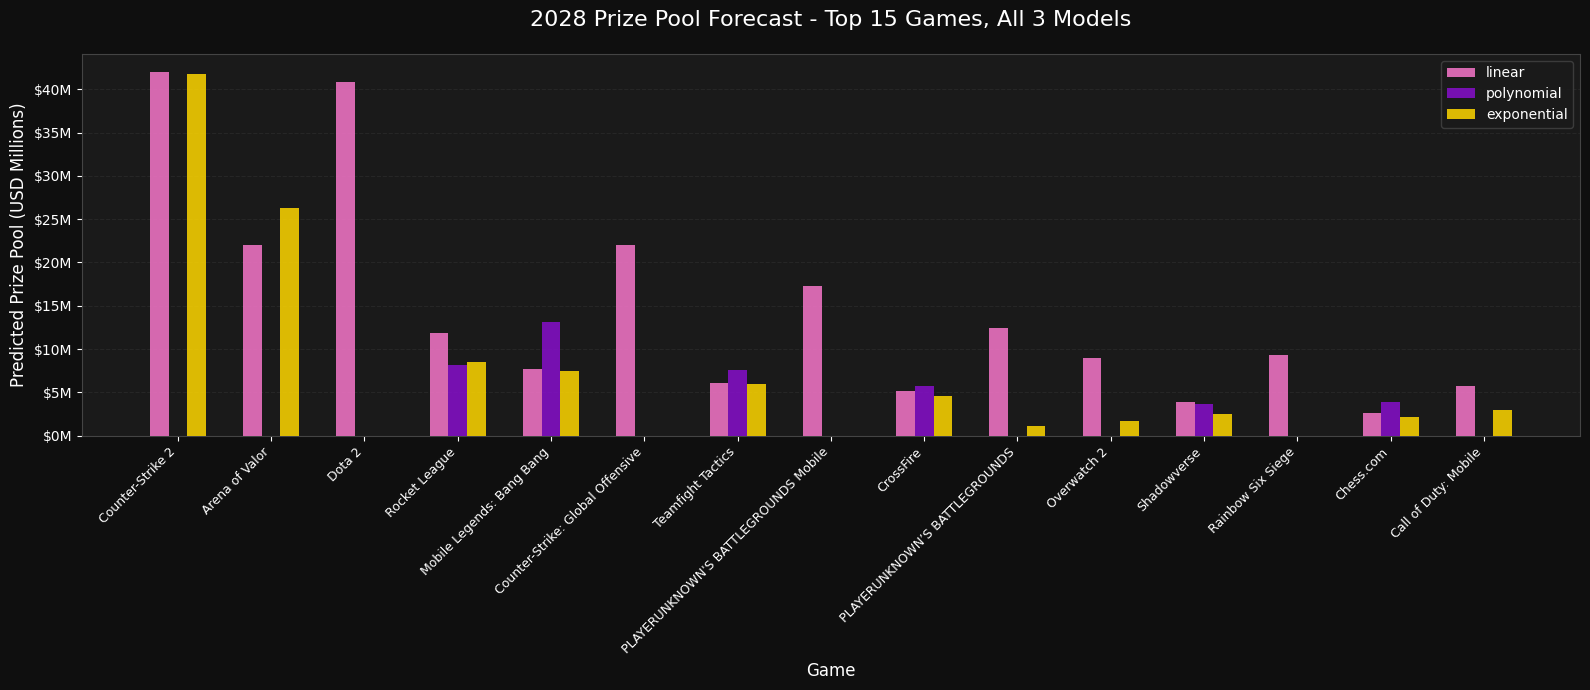

In [183]:
#Get 2028 predictions from all three models
linear_2028 = predictions_df[predictions_df["year"]==2028][["game", "predicted_prize_pool"]].rename(
    columns={"predicted_prize_pool": "linear"})
poly_2028 = poly_df[poly_df["year"]==2028][["game", "predicted_prize_pool"]].rename(
    columns={"predicted_prize_pool": "polynomial"})
exp_2028 = exp_df[exp_df["year"]==2028][["game", "predicted_prize_pool"]].rename(
    columns={"predicted_prize_pool":"exponential"})

combined_2028 = linear_2028.merge(poly_2028, on="game").merge(exp_2028, on="game")
combined_2028["avg_prediction"] = (combined_2028["linear"] + combined_2028["polynomial"] + combined_2028["exponential"])/3
combined_2028 = combined_2028.sort_values("avg_prediction", ascending=False).head(15)

x = np.arange(len(combined_2028))
width=0.2

fig, ax = plt.subplots(figsize=(16,7))

bars1 = ax.bar(x-width, combined_2028["linear"]/1_000_000, 
               width, label="linear", color = "#f776ca", alpha = 0.85, zorder = 3)
bars2 = ax.bar(x, combined_2028["polynomial"]/1_000_000, 
               width, label="polynomial", color = "#870fcc", alpha = 0.85, zorder = 3)
bars2 = ax.bar(x+width, combined_2028["exponential"]/1_000_000, 
               width, label="exponential", color = "#ffd700", alpha = 0.85, zorder = 3)

ax.set_title("2028 Prize Pool Forecast - Top 15 Games, All 3 Models", fontsize = 16, pad=20)
ax.set_xlabel("Game", fontsize=12)
ax.set_ylabel("Predicted Prize Pool (USD Millions)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(combined_2028["game"], rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(facecolor="#1a1a1a", edgecolor="#444444", labelcolor="white")
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

#### Saving Predictions to SQLite:

In [184]:
predictions_df.to_sql("linear_predictions", conn, if_exists = "replace", index = False)
poly_df.to_sql("polynomical_predictions", conn, if_exists = "replace", index = False)
exp_df.to_sql("holts_predictions", conn, if_exists = "replace", index = False)

print("All predictions saved!")

All predictions saved!


In [185]:
tables = pd.read_sql_query("""
    SELECT name FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""", conn)

print(tables.to_string())

                      name
0                    games
1        holts_predictions
2       linear_predictions
3  polynomical_predictions
4              tournaments
5           yearly_summary


## Phase 6: Summary Table & Conclusions

### Model Predictions Summary Table:

In [186]:
#Pull 028 predictions from all three models
linear_summary = predictions_df[predictions_df["year"]==2028][["game", "predicted_prize_pool", "r_squared_linear"]].rename(
    columns={"predicted_prize_pool": "linear_2028", "r_squared_linear": "linear_r2"})

poly_summary = poly_df[poly_df["year"]==2028][["game", "predicted_prize_pool", "r_squared_poly"]].rename(
    columns={"predicted_prize_pool": "poly_2028", "r_squared_poly": "poly_r2"})

exp_summary = exp_df[predictions_df["year"]==2028][["game", "predicted_prize_pool", "mae", "alpha"]].rename(
    columns={"predicted_prize_pool": "holts_2028"})

#Merge all three together
summary = linear_summary.merge(poly_summary, on="game").merge(exp_summary, on="game")

#Add an average predictions column
summary["average_2028"] = (summary["linear_2028"] + summary["poly_2028"] + summary["holts_2028"]) /3

#Add a model agreement column, i.e. spread of predictions
summary["model_spread"] = (summary[["linear_2028", "poly_2028", "holts_2028"]].max(axis=1)-
                           summary[["linear_2028", "poly_2028", "holts_2028"]].min(axis=1)
                        )

summary = summary.sort_values("average_2028", ascending=False).reset_index(drop=True) #reset_index(drop=True) forgets the old indexing values

#Format for display
display_summary = summary.copy()
for col in ["linear_2028", "poly_2028", "holts_2028", "average_2028", "model_spread"]:
    display_summary[col] = display_summary[col].apply(lambda x: f"${x:,.0f}")
display_summary["mae"] = display_summary["mae"].apply(lambda x: f"${x:,.0f}")
display_summary["linear_r2"] = display_summary["linear_r2"].apply(lambda x: f"{x:,.3f}")
display_summary["poly_r2"] = display_summary["poly_r2"].apply(lambda x: f"{x:,.3f}")
display_summary["alpha"] = display_summary["alpha"].apply(lambda x: f"{x:,.3f}")

print(display_summary.to_string())


                                    game  linear_2028 linear_r2    poly_2028 poly_r2   holts_2028          mae  alpha average_2028 model_spread
0                       Counter-Strike 2  $41,994,915     0.689           $0   0.837  $41,799,238   $6,757,731  0.255  $27,931,384  $41,994,915
1                         Arena of Valor  $22,028,006     0.290           $0   0.687  $26,303,781   $4,395,146  0.000  $16,110,596  $26,303,781
2                                 Dota 2  $40,789,149     0.075           $0   0.628           $0  $11,660,952  0.458  $13,596,383  $40,789,149
3                          Rocket League  $11,895,717     0.821   $8,193,469   0.857   $8,475,511   $1,018,450  1.000   $9,521,565   $3,702,248
4              Mobile Legends: Bang Bang   $7,755,123     0.874  $13,160,884   0.947   $7,489,131     $711,338  0.719   $9,468,379   $5,671,754
5       Counter-Strike: Global Offensive  $21,986,918     0.107           $0   0.852           $0   $5,351,633  0.924   $7,328,973  $21,

# Esports Prize Pool Analysis — Conclusions

## 1. Project Summary
In this project, we analyzed the growth and decline of the (qualifying) top 100 competitive esports from their starts to 2025 using tournament and prize pool data scraped from esportsearnings.com. Data was stored in a SQLite database and analyzed using SQL, Pandas, and NumPy. Three predictive models — linear regression, polynomial regression, and Holt's linear exponential smoothing — were used to forecast prize pool growth through 2028 for the 71 games with sufficient historical data.

---

## 2. Key Findings

### Industry Growth
- Global esports prize pools grew from approximately $50,500 in 1998 to $270,234,565 in 2021, 
  representing roughly 535,018% growth over 23 years.
- Global esports has declined slightly from its peak in 2021, falling to $191,191,581 in 2024. (Data for 2025 is missing a significant portion of games on esportsearnings.com, so we exclude 2025 from the conclusions).

### Dominant Games
- Dota 2 has been the single largest prize pool contributor of all time at $382,278,250. This is largely driven by their tournament, "The International," which has community-funded prize pools, which exceeded $40,000,000 in 2021, and frequently exceeds $10,000,000. 
- Counter-Strike 2 and Valorant have awarded the largest prize-pools of any "New Era" game (games with professional scene data starting 2019 or later). 

### Interesting Observations
- There was a decline in popularity in 2020 for many of the top games (easily seem in the popularity-by-era heatmap). This could be due to the COVID-19 pandemic. Games which bucked this trend include Rainbow Six Siege, PUBG Mobile, and Valorant. This is interesting because although Valorant was a brand new game with anticipation among Riot Games fans, Rainbow Six Siege and PUBG Mobile had been released years before, and grew despite the decline many similar games saw.
- Games such as Heroes of the Storm and Counter-Strike have seen the largest decline from their peaks. Although Counter-Strike was released in 2000 and was expected to decline with the release of Counter-Strike: Global Offensive, and Counter-Strike 2, Heroes of the Storm was released in 2015 by Blizzard Entertainment (World of Warcraft, Overwatch 2, Hearthstone) and was ultimately canceled major esports activity in 2018 due to a lack of profitability, demonstrating the difficultly of entering the MOBA professional scene with competitors such as Dota 2 and League of Legends. 
- Mobile esports, particularly PUBG Mobile, emerged as a major force after 2018.

---

## 3. Model Performance

### Linear Regression
- R-squared was generally low across most games, indicating that prize pool growth is not linear for most titles.
- Performed best for Teamfight Tactics and Mobile Legends: Bang Bang, with R-squared values of 0.967 and 0.874, respectively, suggesting relatively steady growth for those titles.
- Tends to overestimate for games with sharp peaks in their history.

### Polynomial Regression
- Improved R-squared scores across most games compared to linear regression.
- In general, unsatisfying results with the polynomial regression. With large booms/busts of games like Dota 2, polynomial regression has unrealistic predictions for most games--most notably, Dota 2, which is predicts to have a $0 prize pool in 2028, even though it is the largest current esport.
- Risk of overfitting noted — degree 2 was chosen deliberately to avoid unrealistic extrapolations.

### Holt's Linear Exponential Smoothing
- Most nuanced of the three models due to its ability to weight recent data more heavily.
- Games with high alpha values (close to 1), such as Rocket League, indicate a sharp recent trend change that dominates the forecast.
- Games with low alpha values such as Arena of Valor have more historically consistent patterns.
- MAE ranged from $32,585 to $25,984,847 across all games.

### Model Agreement
- The three models showed strongest agreement for games with $0 predicted prize pool in 2028, such as Heroes of Newarth, Heroes of the Storm, and Call of Duty: Warzone. Games with relatively low model spread and predicted growth include Teamfight Tactics and Crossfire. 
- The widest disagreement was seen in Counter-Strike 2, reflecting the unreliability of the polynomial regression model in particular, which skews the model spread heavily. 

---

## 4. Data Limitations
- All data was sourced from esportsearnings.com, which relies on community contributions and may be incomplete.
- Teamfight Tactics data is known to be incomplete, with recent tournaments missing from the dataset. So, although the model was able to predict TFT growth with relatively high R-squared values, including more recent tournament data could impact these results. 
- Mobile esports titles, especially, appear underrepresented relative to their actual prize pool activity.
- A formal train/test split was not implemented due to limited yearly data points per game — typically 8-12 years — which is insufficient for reliably testing validity of predictions.

---

## 5. Future Improvements
- Incorporate viewership data from Esports Charts to build a more complete picture of game health/growth beyond prize pools alone.
- Investigate regional breakdowns - prize pool distribution between NA, EU, and Asian markets may give a more complete picture of growth/decline of games around the world. 
- Further break down data, using monthly prize pools rather than yearly prize pools. This may allow for a train-test split since we'd have ~100 data points for each game rather than ~10. 
- Revisit TFT and other underrepresented games with a more complete data source. 